<a href="https://colab.research.google.com/github/evellynjardini/Data-Analytics---Grupo-24/blob/main/1%20-%20Projeto-Olist-KPIs/notebooks/Receita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import pandas as pd

# Monta o seu Google Drive
drive.mount('/content/drive')

caminho_arquivo = '/content/drive/MyDrive/df_consolidado.csv'
df_consolidado = pd.read_csv(caminho_arquivo)

df_consolidado.head()

Mounted at /content/drive


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,price,freight_value,...,product_category_name_english,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_city_clean,seller_zip_code_prefix,seller_city,seller_state,atrasado
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,...,housewares,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,Sao Paulo,9350.0,Maua,SP,False
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,...,perfumery,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,Barreiras,31570.0,Belo Horizonte,SP,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,...,auto,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,Vianopolis,14840.0,Guariba,SP,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,...,pet_shop,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,Sao Goncalo Do Amarante,31842.0,Belo Horizonte,MG,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,...,stationery,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,Santo Andre,8752.0,Mogi Das Cruzes,SP,False


In [2]:
# --- KPI 1: Receita Total ao Longo do Tempo (Mensal) ---

# 1. Filtramos apenas os pedidos entregues diretamente da base consolidada

df_receita = df_consolidado[df_consolidado['order_status'] == 'delivered'].copy()

# 2. Garantimos que a coluna de data esteja no formato correto e criamos o Ano-Mês

df_receita['order_purchase_timestamp'] = pd.to_datetime(df_receita['order_purchase_timestamp'])
df_receita['ano_mes'] = df_receita['order_purchase_timestamp'].dt.to_period('M')

# Excluindo o ano de 2016
df_receita = df_receita[df_receita['order_purchase_timestamp'].dt.year != 2016]

# 3. Agregamos a receita (payment_value) e a quantidade por mês
# Como a base é única por pedido, o count('order_id') é único.
tabela_receita_mensal = (
    df_receita
    .groupby('ano_mes', as_index=False)
    .agg(
        receita_total=('payment_value', 'sum'),
        qtd_pedidos=('order_id', 'count')
    )
    .sort_values('ano_mes')
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 1: RECEITA MENSAL {'='*20}")
print(f"Período: {tabela_receita_mensal['ano_mes'].min()} a {tabela_receita_mensal['ano_mes'].max()}")
print(f"Receita Total (Pedidos Entregues): R$ {df_receita['payment_value'].sum():,.2f}")
print(f"Ticket Médio Mensal: R$ {(df_receita['payment_value'].sum() / df_receita['order_id'].nunique()):,.2f}")
print(f"{'='*53}")

tabela_receita_mensal.head(10)

==================== KPI 1: RECEITA MENSAL ====================
Período: 2017-01 a 2018-08
Receita Total (Pedidos Entregues): R$ 15,375,875.44
Ticket Médio Mensal: R$ 159.81


,ano_mes,receita_total,qtd_pedidos
0,2017-01,127545.67,750
1,2017-02,271298.65,1653
2,2017-03,414369.39,2546
3,2017-04,390952.18,2303
4,2017-05,567066.73,3546
5,2017-06,490225.60,3135
6,2017-07,566403.93,3872
7,2017-08,646000.61,4193
8,2017-09,701169.99,4150
9,2017-10,751140.27,4478


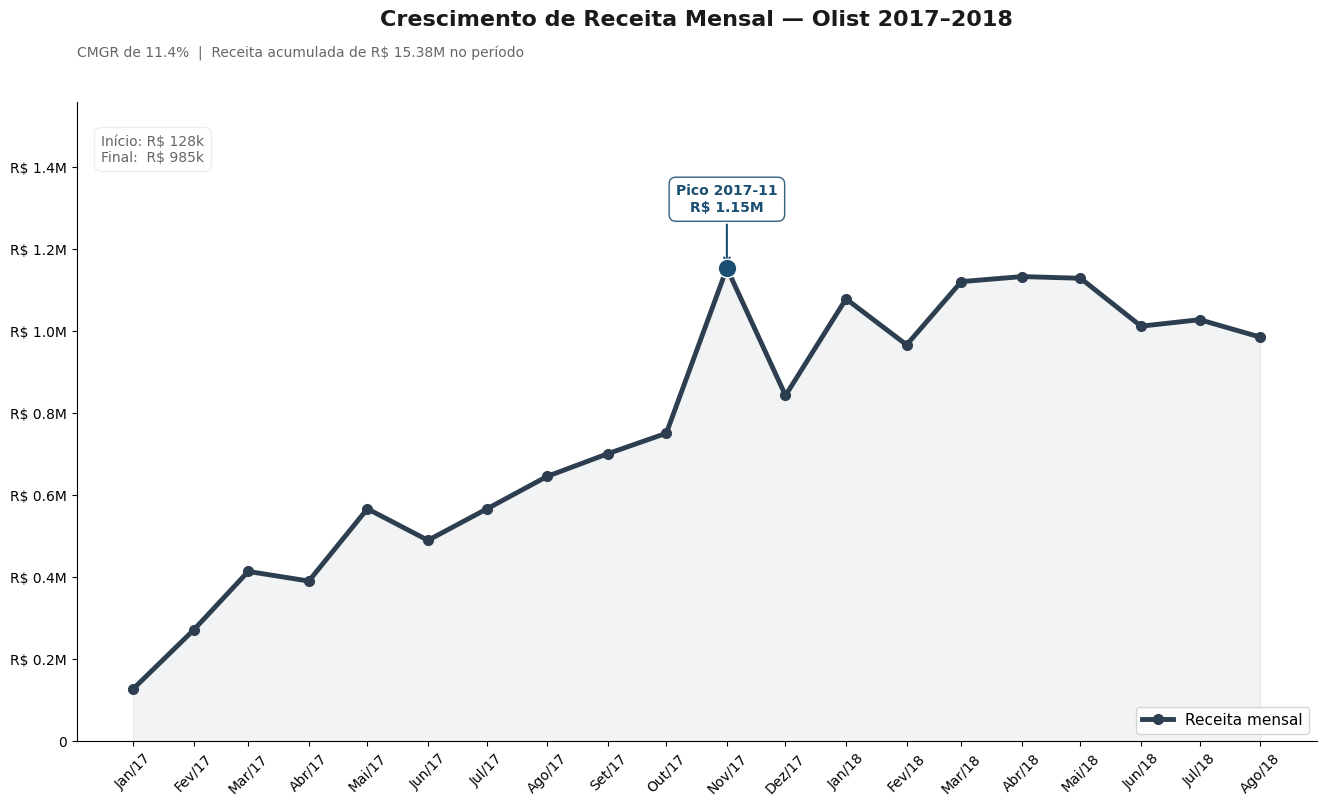

In [3]:
#Gráfico - Receita Mensal
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# --- Preparo dos dados ---
df_plot = (
    tabela_receita_mensal
    .copy()
    .loc[tabela_receita_mensal['ano_mes'].astype(str) >= '2017-01']
    .reset_index(drop=True)
)
df_plot['data'] = pd.to_datetime(df_plot['ano_mes'].astype(str))

# --- Métricas ---
val_inicial   = df_plot['receita_total'].iloc[0]
val_final     = df_plot['receita_total'].iloc[-1]
multiplo      = val_final / val_inicial
n_meses       = len(df_plot) - 1
cmgr          = (multiplo) ** (1 / n_meses) - 1
receita_total = df_plot['receita_total'].sum()

# Pico
idx_pico  = df_plot['receita_total'].idxmax()
data_pico = df_plot.loc[idx_pico, 'data']
val_pico  = df_plot.loc[idx_pico, 'receita_total']
mes_pico  = df_plot.loc[idx_pico, 'ano_mes']

# --- Cores ---
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'

# --- Visualização ---
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
#ax.yaxis.grid(True, linestyle=':', alpha=0.4, color='#cccccc')

# --- Caixa de resumo ---
info_box = f"Início: R$ {val_inicial/1_000:.0f}k\nFinal:  R$ {val_final/1_000:.0f}k"
ax.text(
    0.02, 0.95, info_box, transform=ax.transAxes, fontsize=10,
    bbox=dict(facecolor='white', edgecolor='#eeeeee', boxstyle='round,pad=0.5'),
    color=CINZA_SUB, va='top', zorder=10
)

# --- Linha de receita ---
ax.plot(
    df_plot['data'], df_plot['receita_total'],
    color=AZUL_ESCURO, lw=3.5, marker='o', markersize=7,
    label='Receita mensal', zorder=4
)
ax.fill_between(df_plot['data'], df_plot['receita_total'], alpha=0.06, color=AZUL_ESCURO)

# --- Anotação de pico ---
ax.scatter(data_pico, val_pico, color=COR_PICO, s=180, zorder=5, edgecolor='white')
ax.annotate(
    f'Pico {mes_pico}\nR$ {val_pico/1e6:.2f}M',
    xy=(data_pico, val_pico),
    xytext=(data_pico, val_pico * 1.12),
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.5),
    ha='center', fontweight='bold', color=COR_PICO,
    bbox=dict(boxstyle='round,pad=0.5', fc='white', ec=COR_PICO, alpha=0.9)
)

# --- Eixos ---
meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f"{meses_pt[mdates.num2date(x).month-1]}/{str(mdates.num2date(x).year)[2:]}"
))
ax.yaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f'R$ {x/1e6:.1f}M' if x > 0 else '0'
))
plt.xticks(rotation=45)
ax.set_ylim(0, val_pico * 1.35)

# --- Títulos à esquerda ---
ax.text(
    0.5, 1.12,
    'Crescimento de Receita Mensal — Olist 2017–2018',
    transform=ax.transAxes, fontsize=16, fontweight='bold',
    color=CINZA_TEXTO, ha='center'
)

ax.text(
    0, 1.07,
    f'CMGR de {cmgr*100:.1f}%  |  Receita acumulada de R$ {receita_total/1e6:.2f}M no período',
    transform=ax.transAxes, fontsize=10, color=CINZA_SUB, ha='left'
)

ax.legend(loc='lower right', frameon=True, facecolor='white', fontsize=11)
plt.subplots_adjust(top=0.82)
plt.show()

In [4]:
# --- KPI 2: Ticket Médio ao Longo do Tempo (Mensal) ---

# 1. Utilizamos a tabela_receita_mensal já calculado no KPI receita mensal

# 2. Calculamos o ticket médio mensal (Receita / Quantidade de Pedidos)
tabela_receita_mensal['ticket_medio'] = tabela_receita_mensal['receita_total'] / tabela_receita_mensal['qtd_pedidos']

# --- RESULTADOS ---
print(f"{'='*20} KPI 2: TICKET MÉDIO {'='*20}")

# Calculamos a média real baseada no total de pedidos entregues do df_receita
ticket_medio_geral = df_receita['payment_value'].sum() / df_receita['order_id'].nunique()

print(f"Ticket médio geral (Período Total): R$ {ticket_medio_geral:,.2f}")
print(f"{'='*53}")

# Exibindo as colunas principais
tabela_receita_mensal[['ano_mes', 'qtd_pedidos', 'receita_total', 'ticket_medio']].head(10)

==================== KPI 2: TICKET MÉDIO ====================
Ticket médio geral (Período Total): R$ 159.81


,ano_mes,qtd_pedidos,receita_total,ticket_medio
0,2017-01,750,127545.67,170.060893
1,2017-02,1653,271298.65,164.125015
2,2017-03,2546,414369.39,162.753099
3,2017-04,2303,390952.18,169.757785
4,2017-05,3546,567066.73,159.917296
5,2017-06,3135,490225.60,156.371802
6,2017-07,3872,566403.93,146.282007
7,2017-08,4193,646000.61,154.066446
8,2017-09,4150,701169.99,168.956624
9,2017-10,4478,751140.27,167.740123


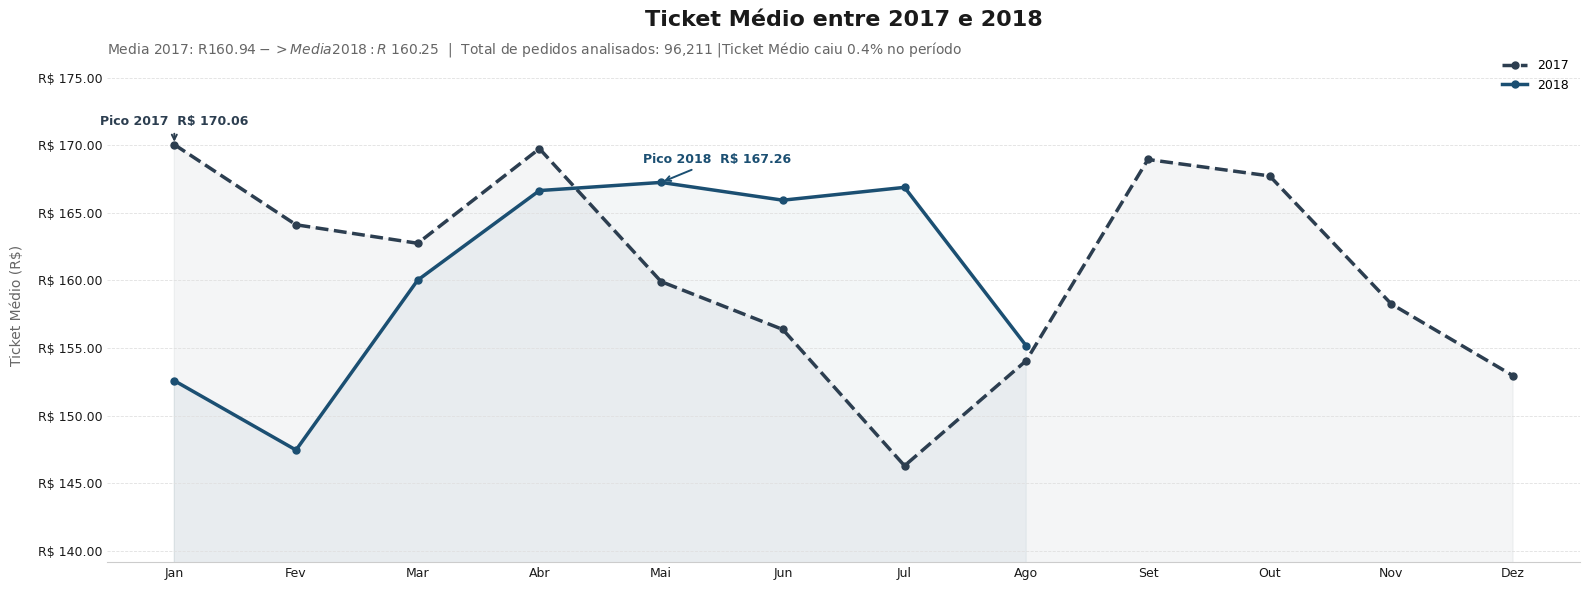

In [5]:
# --- KPI 2: Gráfico Ticket Médio ao Longo do Tempo (Mensal) ---
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Preparação dos dados ───────────────────────────────────────────────────────
df_plot = tabela_receita_mensal.copy()
df_plot['ano_mes_dt'] = df_plot['ano_mes'].dt.to_timestamp()
df_plot['ano'] = df_plot['ano_mes_dt'].dt.year
df_plot['mes'] = df_plot['ano_mes_dt'].dt.month

df_2017 = df_plot[df_plot['ano'] == 2017].reset_index(drop=True)
df_2018 = df_plot[df_plot['ano'] == 2018].reset_index(drop=True)

# ── Cálculo do insight para o título ──────────────────────────────────────────
ticket_2017   = df_2017['ticket_medio'].mean()
ticket_2018   = df_2018['ticket_medio'].mean()
variacao_pct  = ((ticket_2018 - ticket_2017) / ticket_2017) * 100
direcao       = "cresceu" if variacao_pct > 0 else "caiu"
total_pedidos = df_plot['qtd_pedidos'].sum()

idx_pico_2017 = df_2017['ticket_medio'].idxmax()
idx_pico_2018 = df_2018['ticket_medio'].idxmax()

meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

# ── Canvas ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Linha 2017 ────────────────────────────────────────────────────────────────
ax.plot(
    df_2017['mes'], df_2017['ticket_medio'],
    color=AZUL_ESCURO, linewidth=2.5, linestyle='--',
    marker='o', markersize=5, label='2017', zorder=3,
)
ax.fill_between(df_2017['mes'], df_2017['ticket_medio'], alpha=0.05, color=AZUL_ESCURO)

# ── Linha 2018 ────────────────────────────────────────────────────────────────
ax.plot(
    df_2018['mes'], df_2018['ticket_medio'],
    color=COR_PICO, linewidth=2.5,
    marker='o', markersize=5, label='2018', zorder=3,
)
ax.fill_between(df_2018['mes'], df_2018['ticket_medio'], alpha=0.05, color=COR_PICO)


# ── Anotação pico 2017 ────────────────────────────────────────────────────────
ax.annotate(
    f"Pico 2017  R$ {df_2017.loc[idx_pico_2017, 'ticket_medio']:,.2f}",
    xy=(df_2017.loc[idx_pico_2017, 'mes'], df_2017.loc[idx_pico_2017, 'ticket_medio']),
    xytext=(0, 14),
    textcoords='offset points',
    ha='center', fontsize=9, fontweight='bold', color=AZUL_ESCURO,
    arrowprops=dict(arrowstyle='->', color=AZUL_ESCURO, lw=1.4),
)

# ── Anotação pico 2018 ────────────────────────────────────────────────────────
ax.annotate(
    f"Pico 2018  R$ {df_2018.loc[idx_pico_2018, 'ticket_medio']:,.2f}",
    xy=(df_2018.loc[idx_pico_2018, 'mes'], df_2018.loc[idx_pico_2018, 'ticket_medio']),
    xytext=(40, 14),
    textcoords='offset points',
    ha='center', fontsize=9, fontweight='bold', color=COR_PICO,
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.4),
)

# ── Eixos ──────────────────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.2f}'))
ax.set_xticks(range(1, 13))
ax.set_xticklabels(meses_pt, fontsize=9, color=CINZA_TEXTO)
ax.tick_params(axis='y', labelsize=9, colors=CINZA_TEXTO, length=0)
ax.tick_params(axis='x', length=0)

# Limites Y com respiro
margem = (df_plot['ticket_medio'].max() - df_plot['ticket_medio'].min()) * 0.30
ax.set_ylim(
    df_plot['ticket_medio'].min() - margem,
    df_plot['ticket_medio'].max() + margem,
)

# ── Grid e bordas ─────────────────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#e0e0e0', zorder=1)
ax.xaxis.grid(False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.set_ylabel('Ticket Médio (R$)', fontsize=10, color=CINZA_SUB, labelpad=10)

# ── Títulos ───────────────────────────────────────────────────────────────────
ax.set_title(
    f'Ticket Médio entre 2017 e 2018',
    fontsize=16, fontweight='bold', color=CINZA_TEXTO, pad=16, loc='center',
)
ax.text(
    0, 0.98,
    f'Media 2017: R$ {ticket_2017:,.2f}  ->  Media 2018: R$ {ticket_2018:,.2f}  |  '
    f'Total de pedidos analisados: {total_pedidos:,.0f} |'
    f'Ticket Médio {direcao} {abs(variacao_pct):.1f}% no período',
    transform=ax.transAxes, fontsize=10, color=CINZA_SUB, va='bottom',
)

ax.legend(fontsize=9, frameon=False, loc='upper right')

plt.tight_layout()
plt.savefig('ticket_medio_olist.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
import pandas as pd

# 1. Garantimos que temos uma coluna de data real para extrair o mês e o ano
tabela_receita_mensal['data'] = pd.to_datetime(tabela_receita_mensal['ano_mes'].astype(str))
tabela_receita_mensal['ano'] = tabela_receita_mensal['data'].dt.year
tabela_receita_mensal['mes'] = tabela_receita_mensal['data'].dt.month

# 2. Criamos o filtro mágico: Apenas meses de Janeiro (1) a Agosto (8)
df_jan_ago = tabela_receita_mensal[tabela_receita_mensal['mes'] <= 8].copy()

# 3. Calculamos o Ticket Médio Justo para 2017 (Jan a Ago)
df_2017_ytd = df_jan_ago[df_jan_ago['ano'] == 2017]
ticket_2017_ytd = df_2017_ytd['receita_total'].sum() / df_2017_ytd['qtd_pedidos'].sum()

# 4. Calculamos o Ticket Médio Justo para 2018 (Jan a Ago)
df_2018_ytd = df_jan_ago[df_jan_ago['ano'] == 2018]
ticket_2018_ytd = df_2018_ytd['receita_total'].sum() / df_2018_ytd['qtd_pedidos'].sum()

# 5. Calculamos a variação percentual real
variacao_ytd = ((ticket_2018_ytd / ticket_2017_ytd) - 1) * 100

# --- RESULTADOS EXECUTIVOS ---
print(f"\n{'='*20} COMPARAÇÃO JUSTA (JAN a AGO) {'='*20}")
print(f"Ticket Médio 2017 (Jan-Ago): R$ {ticket_2017_ytd:,.2f}")
print(f"Ticket Médio 2018 (Jan-Ago): R$ {ticket_2018_ytd:,.2f}")

if variacao_ytd > 0:
    print(f"Resultado: CRESCIMENTO REAL de {variacao_ytd:.2f}% no Ticket Médio!")
else:
    print(f"Resultado: QUEDA REAL de {abs(variacao_ytd):.2f}% no Ticket Médio.")
print(f"{'='*70}")


==================== COMPARAÇÃO JUSTA (JAN a AGO) ====================
Ticket Médio 2017 (Jan-Ago): R$ 157.92
Ticket Médio 2018 (Jan-Ago): R$ 160.15
Resultado: CRESCIMENTO REAL de 1.41% no Ticket Médio!


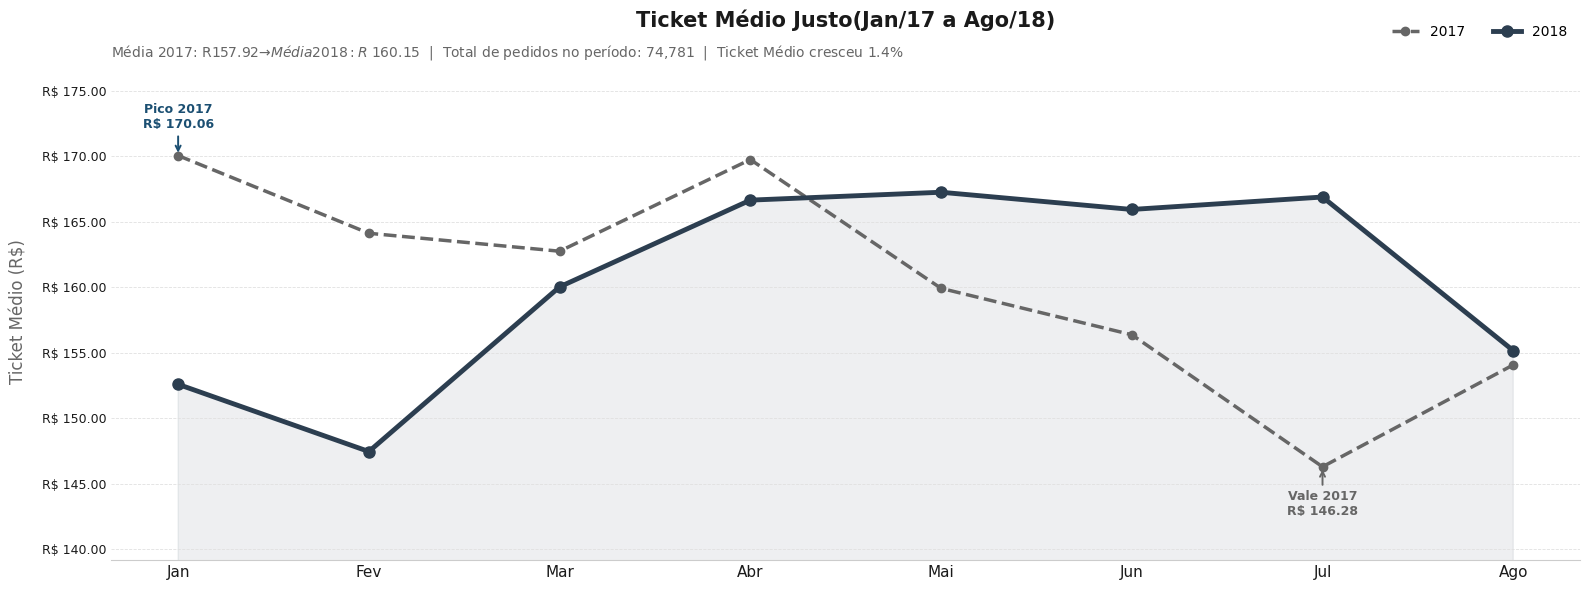

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Preparação dos dados (Filtro Justo: Jan a Ago) ────────────────────────────
df_plot = tabela_receita_mensal.copy()
# Garantimos a extração correta de ano e mês
df_plot['ano_mes_dt'] = pd.to_datetime(df_plot['ano_mes'].astype(str))
df_plot['ano'] = df_plot['ano_mes_dt'].dt.year
df_plot['mes'] = df_plot['ano_mes_dt'].dt.month

# FILTRO MÁGICO: Apenas meses de Janeiro (1) a Agosto (8)
df_justo = df_plot[(df_plot['mes'] <= 8) & (df_plot['ano'].isin([2017, 2018]))].copy()

# Separamos as bases de cada ano
df_2017 = df_justo[df_justo['ano'] == 2017].sort_values('mes')
df_2018 = df_justo[df_justo['ano'] == 2018].sort_values('mes')

# ── Cálculo do insight para o título ──────────────────────────────────────────
ticket_2017 = df_2017['receita_total'].sum() / df_2017['qtd_pedidos'].sum()
ticket_2018 = df_2018['receita_total'].sum() / df_2018['qtd_pedidos'].sum()
variacao_pct = ((ticket_2018 - ticket_2017) / ticket_2017) * 100
direcao = "cresceu" if variacao_pct > 0 else "caiu"
total_pedidos = df_justo['qtd_pedidos'].sum()
ticket_medio_geral = df_justo['ticket_medio'].mean()

# Encontrando o Pico e Vale absolutos dentro do período justo
row_pico = df_justo.loc[df_justo['ticket_medio'].idxmax()]
row_vale = df_justo.loc[df_justo['ticket_medio'].idxmin()]

# Lista de meses para usar no eixo X
meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago']

# ── Canvas ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 1. Linha 2017 (Tracejada, servindo como base de comparação)
ax.plot(
    meses_nomes,
    df_2017['ticket_medio'],
    color=CINZA_SUB,
    linewidth=2.5,
    linestyle='--',
    marker='o',
    markersize=6,
    zorder=3,
    label='2017'
)

# 2. Linha 2018 (Sólida, cor principal)
ax.plot(
    meses_nomes,
    df_2018['ticket_medio'],
    color=AZUL_ESCURO,
    linewidth=3.5,
    marker='o',
    markersize=8,
    zorder=4,
    label='2018'
)

# Área sob a curva apenas para 2018 (para dar destaque ao ano atual)
ax.fill_between(
    meses_nomes,
    df_2018['ticket_medio'],
    alpha=0.08,
    color=AZUL_ESCURO,
)

# Linha de média tracejada em LARANJA (Média do período todo)
'''ax.axhline(
    ticket_medio_geral,
    color=LARANJA,
    linewidth=1.4,
    linestyle='--',
    zorder=2,
    label=f'Média Jan-Ago  R$ {ticket_medio_geral:,.2f}',
)'''

# ── Anotações Dinâmicas (Pico e Vale) ──────────────────────────────────────────
# Pegamos o nome do mês na lista usando o número do mês (-1 porque lista começa em 0)
x_pico = meses_nomes[int(row_pico['mes']) - 1]
ax.annotate(
    f"Pico {int(row_pico['ano'])}\nR$ {row_pico['ticket_medio']:,.2f}",
    xy=(x_pico, row_pico['ticket_medio']),
    xytext=(0, 20),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color=COR_PICO,
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.4),
)

x_vale = meses_nomes[int(row_vale['mes']) - 1]
ax.annotate(
    f"Vale {int(row_vale['ano'])}\nR$ {row_vale['ticket_medio']:,.2f}",
    xy=(x_vale, row_vale['ticket_medio']),
    xytext=(0, -35),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color=CINZA_SUB,
    arrowprops=dict(arrowstyle='->', color=CINZA_SUB, lw=1.4),
)

# ── Eixos e Estilização ────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.2f}'))

plt.xticks(fontsize=11, color=CINZA_TEXTO)
plt.yticks(fontsize=9, color=CINZA_TEXTO)

# Limites Y com respiro
margem = (df_justo['ticket_medio'].max() - df_justo['ticket_medio'].min()) * 0.3
ax.set_ylim(
    df_justo['ticket_medio'].min() - margem,
    df_justo['ticket_medio'].max() + margem,
)

# Grid leve
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#e0e0e0', zorder=1)
ax.xaxis.grid(False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', length=0)

# ── Títulos com insight dinâmico ───────────────────────────────────────────────
ax.set_title(
    f'Ticket Médio Justo(Jan/17 a Ago/18)',
    fontsize=15,
    fontweight='bold',
    color=CINZA_TEXTO,
    pad=25,
    loc='center',
)
ax.text(
    0, 1.0,
    f'Média 2017: R$ {ticket_2017:,.2f}  →  Média 2018: R$ {ticket_2018:,.2f}  |  Total de pedidos no período: {total_pedidos:,.0f}  |  '
    f'Ticket Médio {direcao} {abs(variacao_pct):.1f}%',
    transform=ax.transAxes,
    fontsize=10,
    color=CINZA_SUB,
    va='bottom',
)
ax.set_xlabel('')
ax.set_ylabel('Ticket Médio (R$)', fontsize=12, color=CINZA_SUB, labelpad=10)

# Legenda ajustada
ax.legend(
    fontsize=10,
    frameon=False,
    loc='upper right',
    bbox_to_anchor=(1.0, 1.1), # Joga a legenda lá pro cantinho superior direito
    ncol=3
)

plt.tight_layout()
plt.savefig('ticket_medio_justo_olist.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
from google.colab import files

df_receita.to_excel('df_receita.xlsx', index=False)

files.download('df_receita.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [9]:
# 3. Dicionário para padronização das categorias de produtos.
mapa_categorias = {
    # Alimentos
    'alimentos_bebidas': 'alimentos',

    # Casa / conforto
    'casa_conforto_2': 'casa_conforto',

    # Construção (ajuste fino incluído)
    'casa_construcao': 'construcao',
    'construcao_ferramentas_construcao': 'construcao',
    'construcao_ferramentas_ferramentas': 'construcao',
    'construcao_ferramentas_iluminacao': 'construcao',
    'construcao_ferramentas_jardim': 'construcao',
    'construcao_ferramentas_seguranca': 'construcao',

    # Eletrodomésticos
    'eletrodomesticos_2': 'eletrodomesticos',

    # CDs / DVDs / música
    'dvds_blu_ray': 'cds_dvds_musicais',
    'musica': 'cds_dvds_musicais',

    # Livros
    'livros_importados': 'livros',
    'livros_interesse_geral': 'livros',
    'livros_tecnicos': 'livros',

    # Moda → Vestuário
    'fashion_bolsas_e_acessorios': 'vestuario',
    'fashion_calcados': 'vestuario',
    'fashion_esporte': 'vestuario',
    'fashion_roupa_feminina': 'vestuario',
    'fashion_roupa_infanto_juvenil': 'vestuario',
    'fashion_roupa_masculina': 'vestuario',
    'fashion_underwear_e_moda_praia': 'vestuario',

    # Artes
    'artes_e_artesanato': 'artes',

    # Móveis
    'moveis_colchao_e_estofado': 'moveis',
    'moveis_cozinha_area_de_servico_jantar_e_jardim': 'moveis',
    'moveis_decoracao': 'moveis',
    'moveis_escritorio': 'moveis',
    'moveis_quarto': 'moveis',
    'moveis_sala': 'moveis',

    # Portáteis cozinha
    'portateis_casa_forno_e_cafe': 'eletroportateis',
    'portateis_cozinha_e_preparadores_de_alimentos': 'eletroportateis',

    # Telefonia
    'telefonia_fixa': 'telefonia',

    # Segurança
    'sinalizacao_e_seguranca': 'seguranca',
    'seguros_e_servicos': 'seguranca',

    # Informática
    'pcs': 'informatica',
    'pc_gamer': 'informatica',
    'tablets_impressao_imagem': 'informatica',
    'informatica_acessorios': 'informatica',

    # Indústria / comércio
    'industria_comercio_e_negocios': 'industria_comercio',
    'agro_industria_e_comercio': 'industria_comercio',


}

In [11]:
# KP3 - Receita por Categoria

df_itens_pedido = pd.read_csv('/content/olist_order_items_dataset.csv', encoding='utf-8')
df_produtos = pd.read_csv('/content/olist_products_dataset.csv',encoding='utf-8')
df_pedidos = pd.read_csv('/content/olist_orders_dataset.csv',encoding='utf-8')

df_produtos['product_category_clean'] = (
    df_produtos['product_category_name']
    .replace(mapa_categorias)
    .fillna('sem_categoria')

)

df_itens_pcategoria = pd.merge(df_itens_pedido, df_pedidos[['order_id', 'order_status','order_purchase_timestamp']], on='order_id', how='inner')
df_itens_pcategoria = pd.merge(df_itens_pcategoria, df_produtos[['product_id', 'product_category_clean']], on='product_id', how='left')

df_itens_pcategoria[df_itens_pcategoria['order_status'] == 'delivered']
df_itens_pcategoria['order_purchase_timestamp'] = pd.to_datetime(df_itens_pcategoria['order_purchase_timestamp'])


# Excluindo o ano de 2016
df_itens_pcategoria = df_itens_pcategoria[df_itens_pcategoria['order_purchase_timestamp'].dt.year != 2016]


#
# Calculamos a Receita por Categoria

tabela_categorias = (
    df_itens_pcategoria
    .groupby('product_category_clean', as_index=False)
    .agg(receita_produtos=('price', 'sum'))
    .sort_values('receita_produtos', ascending=False)
)

tabela_categorias.head(10)

# receita total de TODAS as categorias juntas
receita_total_absoluta = tabela_categorias['receita_produtos'].sum()

# Top 10 e criamos a coluna de porcentagem
tabela_top10 = tabela_categorias.head(10).copy()
tabela_top10['porcentagem'] = (tabela_top10['receita_produtos'] / receita_total_absoluta) * 100

In [12]:
tabela_top10

,product_category_clean,receita_produtos,porcentagem
8,beleza_saude,1253993.86,9.260132
36,relogios_presentes,1201645.44,8.873564
26,informatica,1142592.49,8.437487
32,moveis,1136183.32,8.390158
10,cama_mesa_banho,1036509.69,7.654117
21,esporte_lazer,984715.33,7.271641
17,cool_stuff,634179.85,4.683108
40,utilidades_domesticas,630961.59,4.659343
5,automotivo,590886.86,4.363411
22,ferramentas_jardim,483896.58,3.573340


In [13]:
tabela_categorias['receita_produtos'].sum()

np.float64(13541857.78)

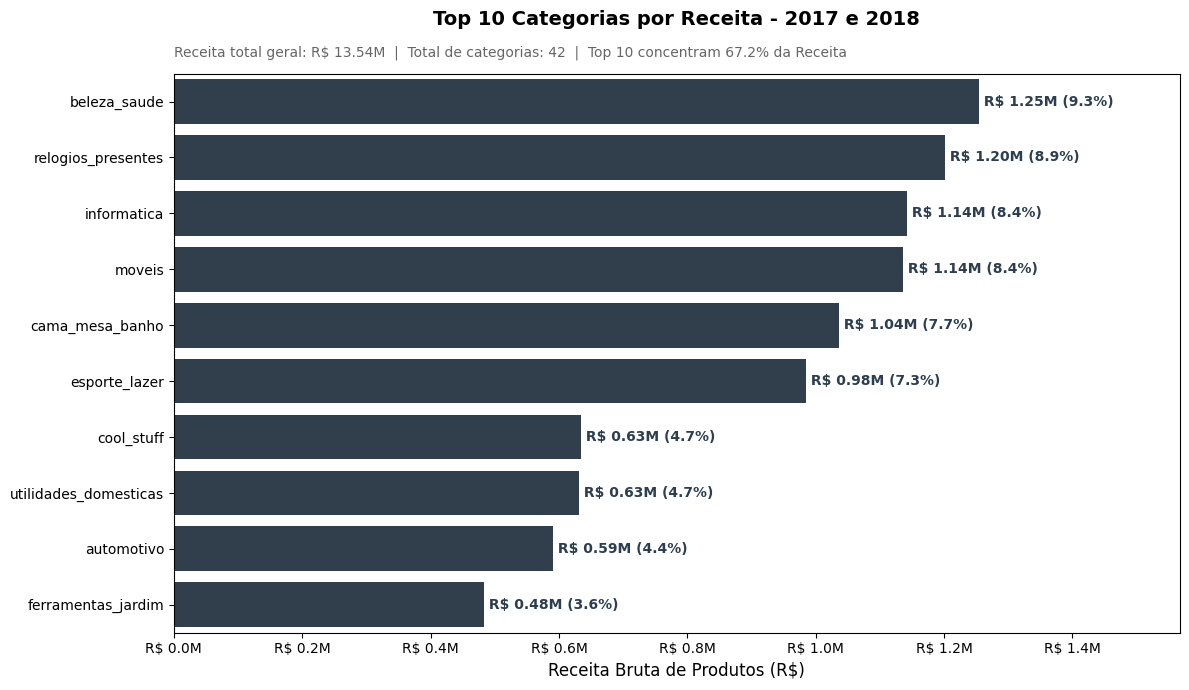

In [14]:
# KP3 - Gráfico de Receita por Categoria

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

receita_total_geral = tabela_categorias['receita_produtos'].sum()
n_categorias        = tabela_categorias['product_category_clean'].nunique()

# Usamos a coluna correta 'receita_produtos' da tabela_top10
top10_share = tabela_top10['receita_produtos'].sum() / receita_total_geral * 100

plt.figure(figsize=(12, 7))

sns.barplot(
    data=tabela_top10,
    y='product_category_clean',
    x='receita_produtos',
    color='#2c3e50'
)

plt.title('Top 10 Categorias por Receita - 2017 e 2018', fontsize=14, fontweight='bold', pad=35)
plt.xlabel('Receita Bruta de Produtos (R$)', fontsize=12)
plt.ylabel('', fontsize=12)

# Formatando o eixo X para Milhões
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'R$ {x/1000000:.1f}M'))

xmax = tabela_top10['receita_produtos'].max()
plt.xlim(0, xmax * 1.25)

# Iterando para colocar os rótulos de dados
for index, row in tabela_top10.reset_index(drop=True).iterrows():
    valor = row['receita_produtos']
    perc = row['porcentagem']
    texto_label = f' R$ {valor/1000000:.2f}M ({perc:.1f}%)'
    plt.text(valor, index, texto_label, va='center', fontsize=10, fontweight='bold', color='#2c3e50')

# Subtítulo corrigido (o texto que você juntou no prompt anterior já estava certinho!)
texto_subtitulo = (
    f"Receita total geral: R$ {receita_total_geral/1e6:.2f}M  |  " +
    f"Total de categorias: {n_categorias}  |  " +
    f"Top 10 concentram {top10_share:.1f}% da Receita"
)

plt.gca().text(
    0, 1.03,
    texto_subtitulo,
    transform=plt.gca().transAxes,
    fontsize=10,
    color='#666666',
    ha='left'
)

plt.tight_layout()
plt.show()

In [15]:
# --- KPI 4: Receita por Estado ---

# 1. Base usada nos indicadores anteriores de Receita

# 2. Tratamos categorias ausentes (Data Cleaning dentro do KPI)

# Usaremos 'product_category_name_english' que é o nome comum após a tradução
col_categoria = 'customer_state'

if col_categoria in df_receita.columns:
    df_receita[col_categoria] = df_receita[col_categoria].fillna('sem_preenchimento')
else:

    col_categoria = 'customer_state'

# 3. Agregamos os valores por categoria
# Como a base é consolidada por pedido, price e freight_value já são os totais do pedido
tabela_receita_por_estado = (
    df_receita
    .groupby(col_categoria, as_index=False)
    .agg(
        receita_produtos=('price', 'sum'),
        receita_frete=('freight_value', 'sum'),
        qtd_pedidos=('order_id', 'count') # Cada linha é um pedido único
    )
    .assign(receita_total=lambda x: x['receita_produtos'] + x['receita_frete'])
    .sort_values('receita_produtos', ascending=False)
    .reset_index(drop=True)
)

# --- RESULTADOS ---
print(f"{'='*20} KPI 4: RECEITA POR ESTADO {'='*20}")
print(f"Total de Estados Analisados: {tabela_receita_por_estado[col_categoria].nunique()}")
print(f"Receita da categoria 'sem_categoria': R$ {tabela_receita_por_estado.loc[tabela_receita_por_estado[col_categoria]=='sem_preenchimento', 'receita_total'].sum():,.2f}")
print(f"{'='*60}")

tabela_receita_por_estado.head(15)

==================== KPI 4: RECEITA POR ESTADO ====================
Total de Estados Analisados: 27
Receita da categoria 'sem_categoria': R$ 0.00


,customer_state,receita_produtos,receita_frete,qtd_pedidos,receita_total
0,SP,5055587.13,700412.63,40406,5755999.76
1,RJ,1751433.85,294923.79,12310,2046357.64
2,MG,1548206.88,265747.39,11319,1813954.27
3,RS,726373.92,132200.76,5328,858574.68
4,PR,664048.00,115166.08,4903,779214.08
5,SC,504774.07,87852.99,3537,592627.06
6,BA,493339.26,97477.54,3253,590816.80
7,DF,295454.64,49468.60,2074,344923.24
8,GO,281932.21,51224.02,1950,333156.23
9,ES,267783.66,48882.46,1992,316666.12


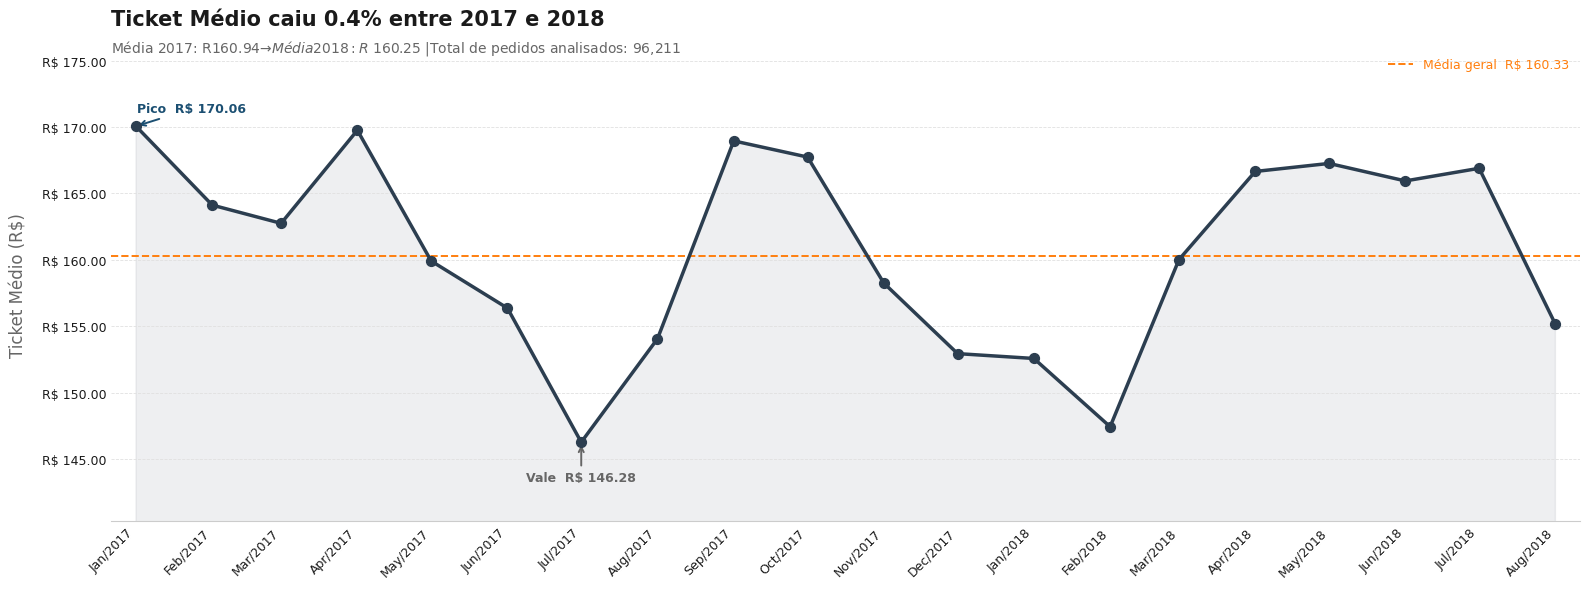

In [18]:
# --- KPI 2: Gráfico Ticket Médio ao Longo do Tempo (Mensal) ---

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Preparação dos dados ───────────────────────────────────────────────────────
df_plot = tabela_receita_mensal.copy()
df_plot['ano_mes_dt'] = df_plot['ano_mes'].dt.to_timestamp()

idx_pico = df_plot['ticket_medio'].idxmax()
idx_vale = df_plot['ticket_medio'].idxmin()

# ── Cálculo do insight para o título ──────────────────────────────────────────
ticket_2017 = df_plot[df_plot['ano_mes_dt'].dt.year == 2017]['ticket_medio'].mean()
ticket_2018 = df_plot[df_plot['ano_mes_dt'].dt.year == 2018]['ticket_medio'].mean()
variacao_pct = ((ticket_2018 - ticket_2017) / ticket_2017) * 100
direcao = "cresceu" if variacao_pct > 0 else "caiu"
total_pedidos= df_plot['qtd_pedidos'].sum()
# ── Canvas ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Linha principal
ax.plot(
    df_plot['ano_mes_dt'],
    df_plot['ticket_medio'],
    color=AZUL_ESCURO,
    linewidth=2.5,
    zorder=3,
)

# Marcadores
ax.scatter(
    df_plot['ano_mes_dt'],
    df_plot['ticket_medio'],
    color=AZUL_ESCURO,
    s=50,
    zorder=4,
)

# Linha de média tracejada em LARANJA
ax.axhline(
    ticket_medio_geral,
    color=LARANJA,
    linewidth=1.4,
    linestyle='--',
    zorder=2,
    label=f'Média geral  R$ {ticket_medio_geral:,.2f}',
)

# Área sob a curva
ax.fill_between(
    df_plot['ano_mes_dt'],
    df_plot['ticket_medio'],
    alpha=0.08,
    color=AZUL_ESCURO,
)

# ── Anotação Pico ──────────────────────────────────────────────────────────────
ax.annotate(
    f"Pico  R$ {df_plot.loc[idx_pico, 'ticket_medio']:,.2f}",
    xy=(df_plot.loc[idx_pico, 'ano_mes_dt'], df_plot.loc[idx_pico, 'ticket_medio']),
    xytext=(40, 10),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color=COR_PICO,
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.4),
)

# ── Anotação Vale ──────────────────────────────────────────────────────────────
ax.annotate(
    f"Vale  R$ {df_plot.loc[idx_vale, 'ticket_medio']:,.2f}",
    xy=(df_plot.loc[idx_vale, 'ano_mes_dt'], df_plot.loc[idx_vale, 'ticket_medio']),
    xytext=(0, -28),
    textcoords='offset points',
    ha='center',
    fontsize=9,
    fontweight='bold',
    color=CINZA_SUB,
    arrowprops=dict(arrowstyle='->', color=CINZA_SUB, lw=1.4),
)

# ── Eixos ──────────────────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.2f}'))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b/%Y'))
ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(interval=1))

plt.xticks(rotation=45, ha='right', fontsize=9, color=CINZA_TEXTO)
plt.yticks(fontsize=9, color=CINZA_TEXTO)

# Limites Y com respiro
margem = (df_plot['ticket_medio'].max() - df_plot['ticket_medio'].min()) * 0.25
ax.set_ylim(
    df_plot['ticket_medio'].min() - margem,
    df_plot['ticket_medio'].max() + margem,
)

# Limites X com respiro lateral
ax.set_xlim(
    df_plot['ano_mes_dt'].min() - pd.DateOffset(days=10),
    df_plot['ano_mes_dt'].max() + pd.DateOffset(days=10),
)

# ── Grid leve ─────────────────────────────────────────────────────────────────
ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#e0e0e0', zorder=1)
ax.xaxis.grid(False)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', length=0)

# ── Títulos com insight dinâmico ───────────────────────────────────────────────
ax.set_title(
    f'Ticket Médio {direcao} {abs(variacao_pct):.1f}% entre 2017 e 2018',
    fontsize=15,
    fontweight='bold',
    color=CINZA_TEXTO,
    pad=16,
    loc='left',
)
ax.text(
    0, 0.98,
    f'Média 2017: R$ {ticket_2017:,.2f}  →  Média 2018: R$ {ticket_2018:,.2f} |'
    f'Total de pedidos analisados: {total_pedidos:,.0f}',
    transform=ax.transAxes,
    fontsize=10,
    color=CINZA_SUB,
    va='bottom',

)


ax.set_xlabel('')
ax.set_ylabel('Ticket Médio (R$)', fontsize=12, color=CINZA_SUB, labelpad=10)

ax.legend(
    fontsize=9,
    frameon=False,
    loc='upper right',
    labelcolor=LARANJA,
)

plt.tight_layout()
plt.savefig('ticket_medio_olist.png', dpi=150, bbox_inches='tight')
plt.show()

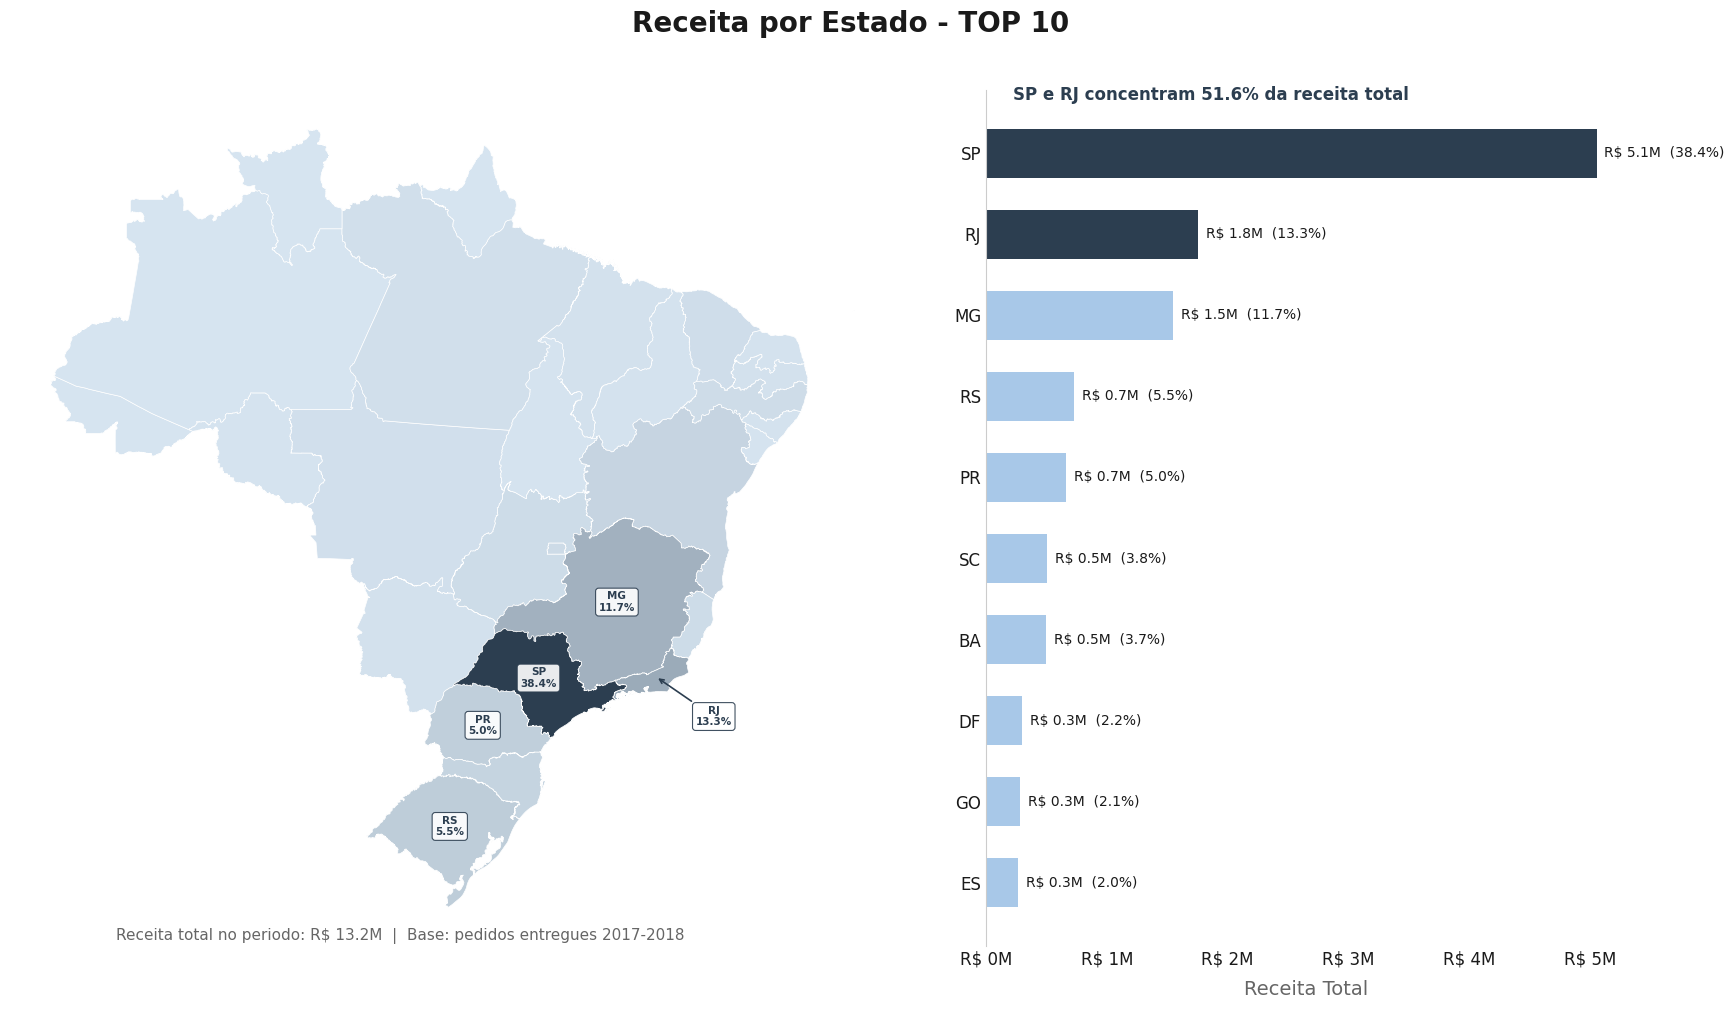

In [32]:
# --- KPI 4: Receita por Estado ---


import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import geopandas as gpd
import requests
import io

#Avisos
import warnings
warnings.filterwarnings('ignore')

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
AZUL_CLARO  = '#a8c8e8'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Baixa o shapefile do Brasil por estado ────────────────────────────────────
url = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
response = requests.get(url)
gdf = gpd.read_file(io.BytesIO(response.content))

gdf = gdf.rename(columns={'sigla': 'customer_state'})

# ── Merge com a tabela de receita ─────────────────────────────────────────────
gdf_merged = gdf.merge(tabela_receita_por_estado[['customer_state', 'receita_produtos']],
                        on='customer_state', how='left')
gdf_merged['receita_produtos'] = gdf_merged['receita_produtos'].fillna(0)

# ── Insight para o título ─────────────────────────────────────────────────────
receita_produtos_geral = tabela_receita_por_estado['receita_produtos'].sum()
top2 = tabela_receita_por_estado.head(2)
top2_receita = top2['receita_produtos'].sum()
top2_pct = (top2_receita / receita_produtos_geral) * 100
top2_estados = ' e '.join(top2['customer_state'].tolist())

# ── Top 10 para o bar chart ───────────────────────────────────────────────────
df_top10 = tabela_receita_por_estado.head(10).sort_values('receita_produtos', ascending=True)

# ── Canvas: Mapa + Bar Chart ──────────────────────────────────────────────────
fig, (ax_mapa, ax_bar) = plt.subplots(
    1, 2,
    figsize=(18, 10),
    gridspec_kw={'width_ratios': [1.5, 1]}
)
fig.patch.set_facecolor('white')

# ────────────────────────────────────────────────────────────────────────────
# MAPA
# ────────────────────────────────────────────────────────────────────────────
ax_mapa.set_facecolor('white')

cmap = mcolors.LinearSegmentedColormap.from_list(
    'azul_gradiente', ['#d6e4f0', AZUL_ESCURO]
)

gdf_merged.plot(
    column='receita_produtos',
    cmap=cmap,
    linewidth=0.5,
    edgecolor='white',
    ax=ax_mapa,
    legend=False,
)

# Anotação dos Top 5 estados no mapa
# Anotação dos Top 5 estados no mapa
top5 = tabela_receita_por_estado.head(5)

# Offsets customizados para estados pequenos
offsets = {
    'SP': (0, 0),
    'RJ': (3,-2),
    'MG': (0, 0),
    'RS': (0, 0),
    'PR': (0, 0),
}

for _, row in top5.iterrows():
    estado = row['customer_state']
    pct = (row['receita_produtos'] / receita_produtos_geral) * 100
    geo_row = gdf_merged[gdf_merged['customer_state'] == estado]
    if not geo_row.empty:
        centroid = geo_row.geometry.centroid.iloc[0]
        ox, oy = offsets.get(estado, (0, 0))

        ax_mapa.annotate(
            f"{estado}\n{pct:.1f}%",
            xy=(centroid.x, centroid.y),
            xytext=(centroid.x + ox, centroid.y + oy),
            ha='center', va='center',
            fontsize=7.5,
            fontweight='bold',
            color=AZUL_ESCURO,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=AZUL_ESCURO, lw=0.8, alpha=0.9),
            arrowprops=dict(arrowstyle='->', color=AZUL_ESCURO, lw=1.2),
        )


ax_mapa.set_axis_off()

# ────────────────────────────────────────────────────────────────────────────
# BAR CHART HORIZONTAL — Top 10
# ────────────────────────────────────────────────────────────────────────────
ax_bar.set_facecolor('white')

cores_bar = [AZUL_ESCURO if i >= len(df_top10) - 2 else AZUL_CLARO
             for i in range(len(df_top10))]

bars = ax_bar.barh(
    df_top10['customer_state'],
    df_top10['receita_produtos'],
    color=cores_bar,
    edgecolor='none',
    height=0.6,
)

# Rótulo de valor nas barras
# Rótulo de valor e percentual nas barras
for bar, val in zip(bars, df_top10['receita_produtos']):
    pct = (val / receita_produtos_geral) * 100
    ax_bar.text(
        bar.get_width() + receita_produtos_geral * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {val/1e6:.1f}M  ({pct:.1f}%)',
        va='center',
        fontsize=10,
        color=CINZA_TEXTO,
    )

ax_bar.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M'))
ax_bar.tick_params(axis='both', length=0, labelsize=12, colors=CINZA_TEXTO)
ax_bar.spines[['top', 'right', 'bottom']].set_visible(False)
ax_bar.spines['left'].set_color('#cccccc')
ax_bar.xaxis.grid(False )
ax_bar.yaxis.grid(False)
ax_bar.set_xlabel('Receita Total', fontsize=14, color=CINZA_SUB, labelpad=8)
#ax_bar.set_title('Top 10 Estados', fontsize=11, fontweight='bold',
                  #color=CINZA_TEXTO, loc='left', pad=10)

# ── Título principal orientado a insight ─────────────────────────────────────
fig.suptitle(
    #f'{top2_estados} concentram {top2_pct:.1f}% da receita total',
    f'Receita por Estado - TOP 10',
    fontsize=20,
    fontweight='bold',
     color= CINZA_TEXTO,
    x=0.5,
    ha='center',
    y=1.01,


)
# 1. Informações técnicas (Alinhado à esquerda)
fig.text(
    0.25, 0.08,
    f'Receita total no periodo: R$ {receita_produtos_geral/1e6:.1f}M  |  Base: pedidos entregues 2017-2018',
    fontsize=11,
    color=CINZA_SUB,
    ha='center' # "ha" significa Horizontal Alignment
)

# 2. destacado (Alinhado à direita)
fig.text(
    0.70, 0.92, # O 'x' no 0.98 empurra o texto lá para a ponta direita
    f'{top2_estados} concentram {top2_pct:.1f}% da receita total',
    fontsize=12,
    fontweight='bold', # Deixa em negrito
    color=AZUL_ESCURO, # Puxa o seu Azul Marinho da paleta (#2c3e50)
    ha='center' # Alinha pela direita para não vazar da tela
)

plt.tight_layout()
plt.savefig('receita_por_estado.png', dpi=150, bbox_inches='tight')
plt.show()

In [21]:
tabela_categorias = (
    df_itens_pcategoria
    .groupby('product_category_clean', as_index=False)
    .agg(
        # 1. Receita Real da Categoria (O que define o Ranking)
        receita_produtos=('price', 'sum'),

        # 2. Custo Logístico atrelado à categoria
        receita_frete=('freight_value', 'sum'),

        # 3. Volume de saída
        qtde_vendida=('order_item_id', 'count')
    )
    # Ordena a tabela exclusivamente pelo valor dos produtos
    .sort_values('receita_produtos', ascending=False)
    .reset_index(drop=True)
)

# Criando uma coluna extra de análise de impacto logístico
tabela_categorias['%_impacto_frete'] = (tabela_categorias['receita_frete'] / tabela_categorias['receita_produtos']) * 100

print(tabela_categorias.head(10))

  product_category_clean  receita_produtos  receita_frete  qtde_vendida  \
0           beleza_saude        1253993.86      181617.37          9619   
1     relogios_presentes        1201645.44      100428.13          5986   
2            informatica        1142592.49      158173.38          8101   
3                 moveis        1136183.32      275957.14         10881   
4        cama_mesa_banho        1036509.69      204565.45         11107   
5          esporte_lazer         984715.33      168014.04          8622   
6             cool_stuff         634179.85       83822.99          3788   
7  utilidades_domesticas         630961.59      145893.64          6952   
8             automotivo         590886.86       92239.90          4223   
9     ferramentas_jardim         483896.58       98857.44          4342   

   %_impacto_frete  
0        14.483115  
1         8.357551  
2        13.843376  
3        24.288082  
4        19.735990  
5        17.062194  
6        13.217542  
7     

GRÁFICOS AJUSTADOS PARA O WORD

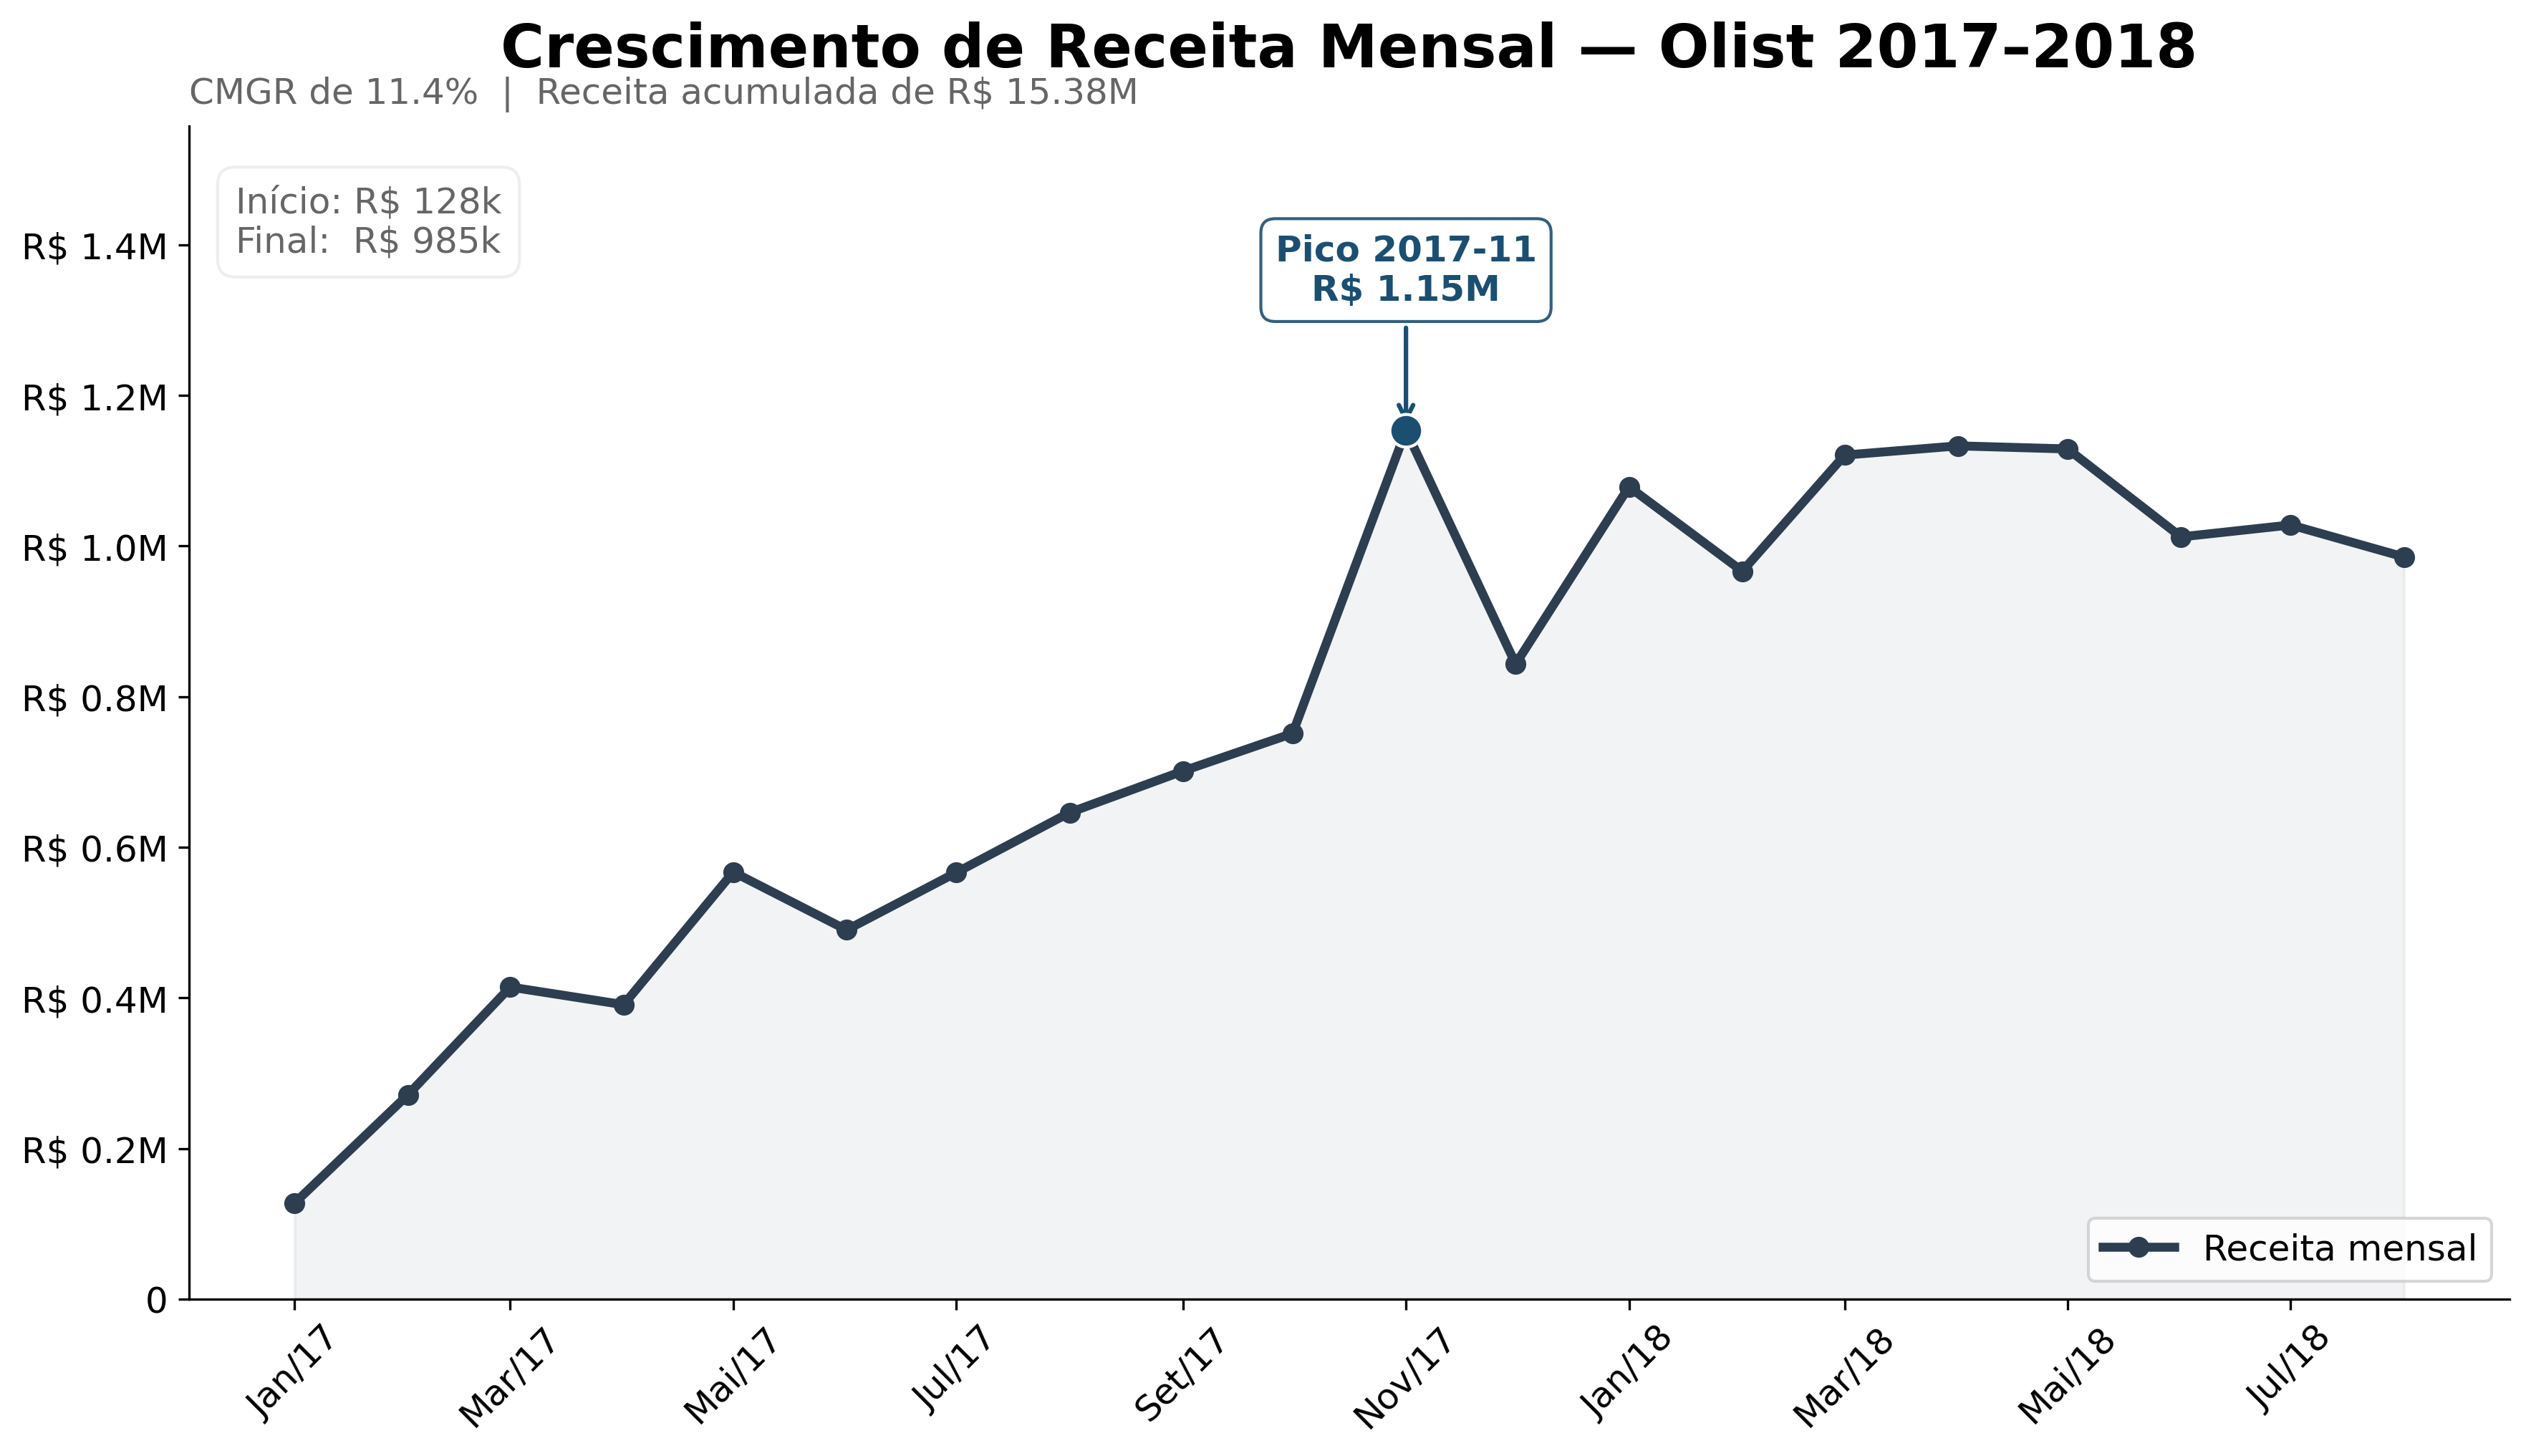

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

# --- Preparo dos dados ---
df_plot = (
    tabela_receita_mensal
    .copy()
    .loc[tabela_receita_mensal['ano_mes'].astype(str) >= '2017-01']
    .reset_index(drop=True)
)
df_plot['data'] = pd.to_datetime(df_plot['ano_mes'].astype(str))

# --- Métricas ---
val_inicial   = df_plot['receita_total'].iloc[0]
val_final     = df_plot['receita_total'].iloc[-1]
multiplo      = val_final / val_inicial
n_meses       = len(df_plot) - 1
cmgr          = (multiplo) ** (1 / n_meses) - 1
receita_total = df_plot['receita_total'].sum()

# Pico
idx_pico  = df_plot['receita_total'].idxmax()
data_pico = df_plot.loc[idx_pico, 'data']
val_pico  = df_plot.loc[idx_pico, 'receita_total']
mes_pico  = df_plot.loc[idx_pico, 'ano_mes']

# --- Cores ---
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'

# --- Config global de fontes ---
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 20,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

# --- Visualização ---
fig, ax = plt.subplots(figsize=(12, 7), dpi=300)  # melhor para Word
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# --- Caixa de resumo ---
info_box = f"Início: R$ {val_inicial/1_000:.0f}k\nFinal:  R$ {val_final/1_000:.0f}k"
ax.text(
    0.02, 0.95, info_box, transform=ax.transAxes, fontsize=12,
    bbox=dict(facecolor='white', edgecolor='#eeeeee', boxstyle='round,pad=0.5'),
    color=CINZA_SUB, va='top', zorder=10
)

# --- Linha de receita ---
ax.plot(
    df_plot['data'], df_plot['receita_total'],
    color=AZUL_ESCURO, lw=3, marker='o', markersize=6,
    label='Receita mensal', zorder=4
)
ax.fill_between(df_plot['data'], df_plot['receita_total'], alpha=0.06, color=AZUL_ESCURO)

# --- Anotação de pico ---
ax.scatter(data_pico, val_pico, color=COR_PICO, s=120, zorder=5, edgecolor='white')
ax.annotate(
    f'Pico {mes_pico}\nR$ {val_pico/1e6:.2f}M',
    xy=(data_pico, val_pico),
    xytext=(data_pico, val_pico * 1.15),
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.5),
    ha='center', fontweight='bold', fontsize=12, color=COR_PICO,
    bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=COR_PICO, alpha=0.9)
)

# --- Eixos ---
meses_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))  # menos poluição
ax.xaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f"{meses_pt[mdates.num2date(x).month-1]}/{str(mdates.num2date(x).year)[2:]}"
))

ax.yaxis.set_major_formatter(FuncFormatter(
    lambda x, p: f'R$ {x/1e6:.1f}M' if x > 0 else '0'
))

plt.xticks(rotation=45)
ax.set_ylim(0, val_pico * 1.35)

# --- Títulos ---
ax.set_title(
    'Crescimento de Receita Mensal — Olist 2017–2018',
    loc='center', pad=20, fontweight='bold'
)

ax.text(
    0, 1.02,
    f'CMGR de {cmgr*100:.1f}%  |  Receita acumulada de R$ {receita_total/1e6:.2f}M',
    transform=ax.transAxes, fontsize=12, color=CINZA_SUB
)

# --- Legenda ---
ax.legend(loc='lower right', frameon=True, facecolor='white')

plt.tight_layout()

# --- SALVAR (ESSENCIAL PARA WORD) ---
plt.savefig('grafico_receita.png', dpi=300, bbox_inches='tight')
plt.show()

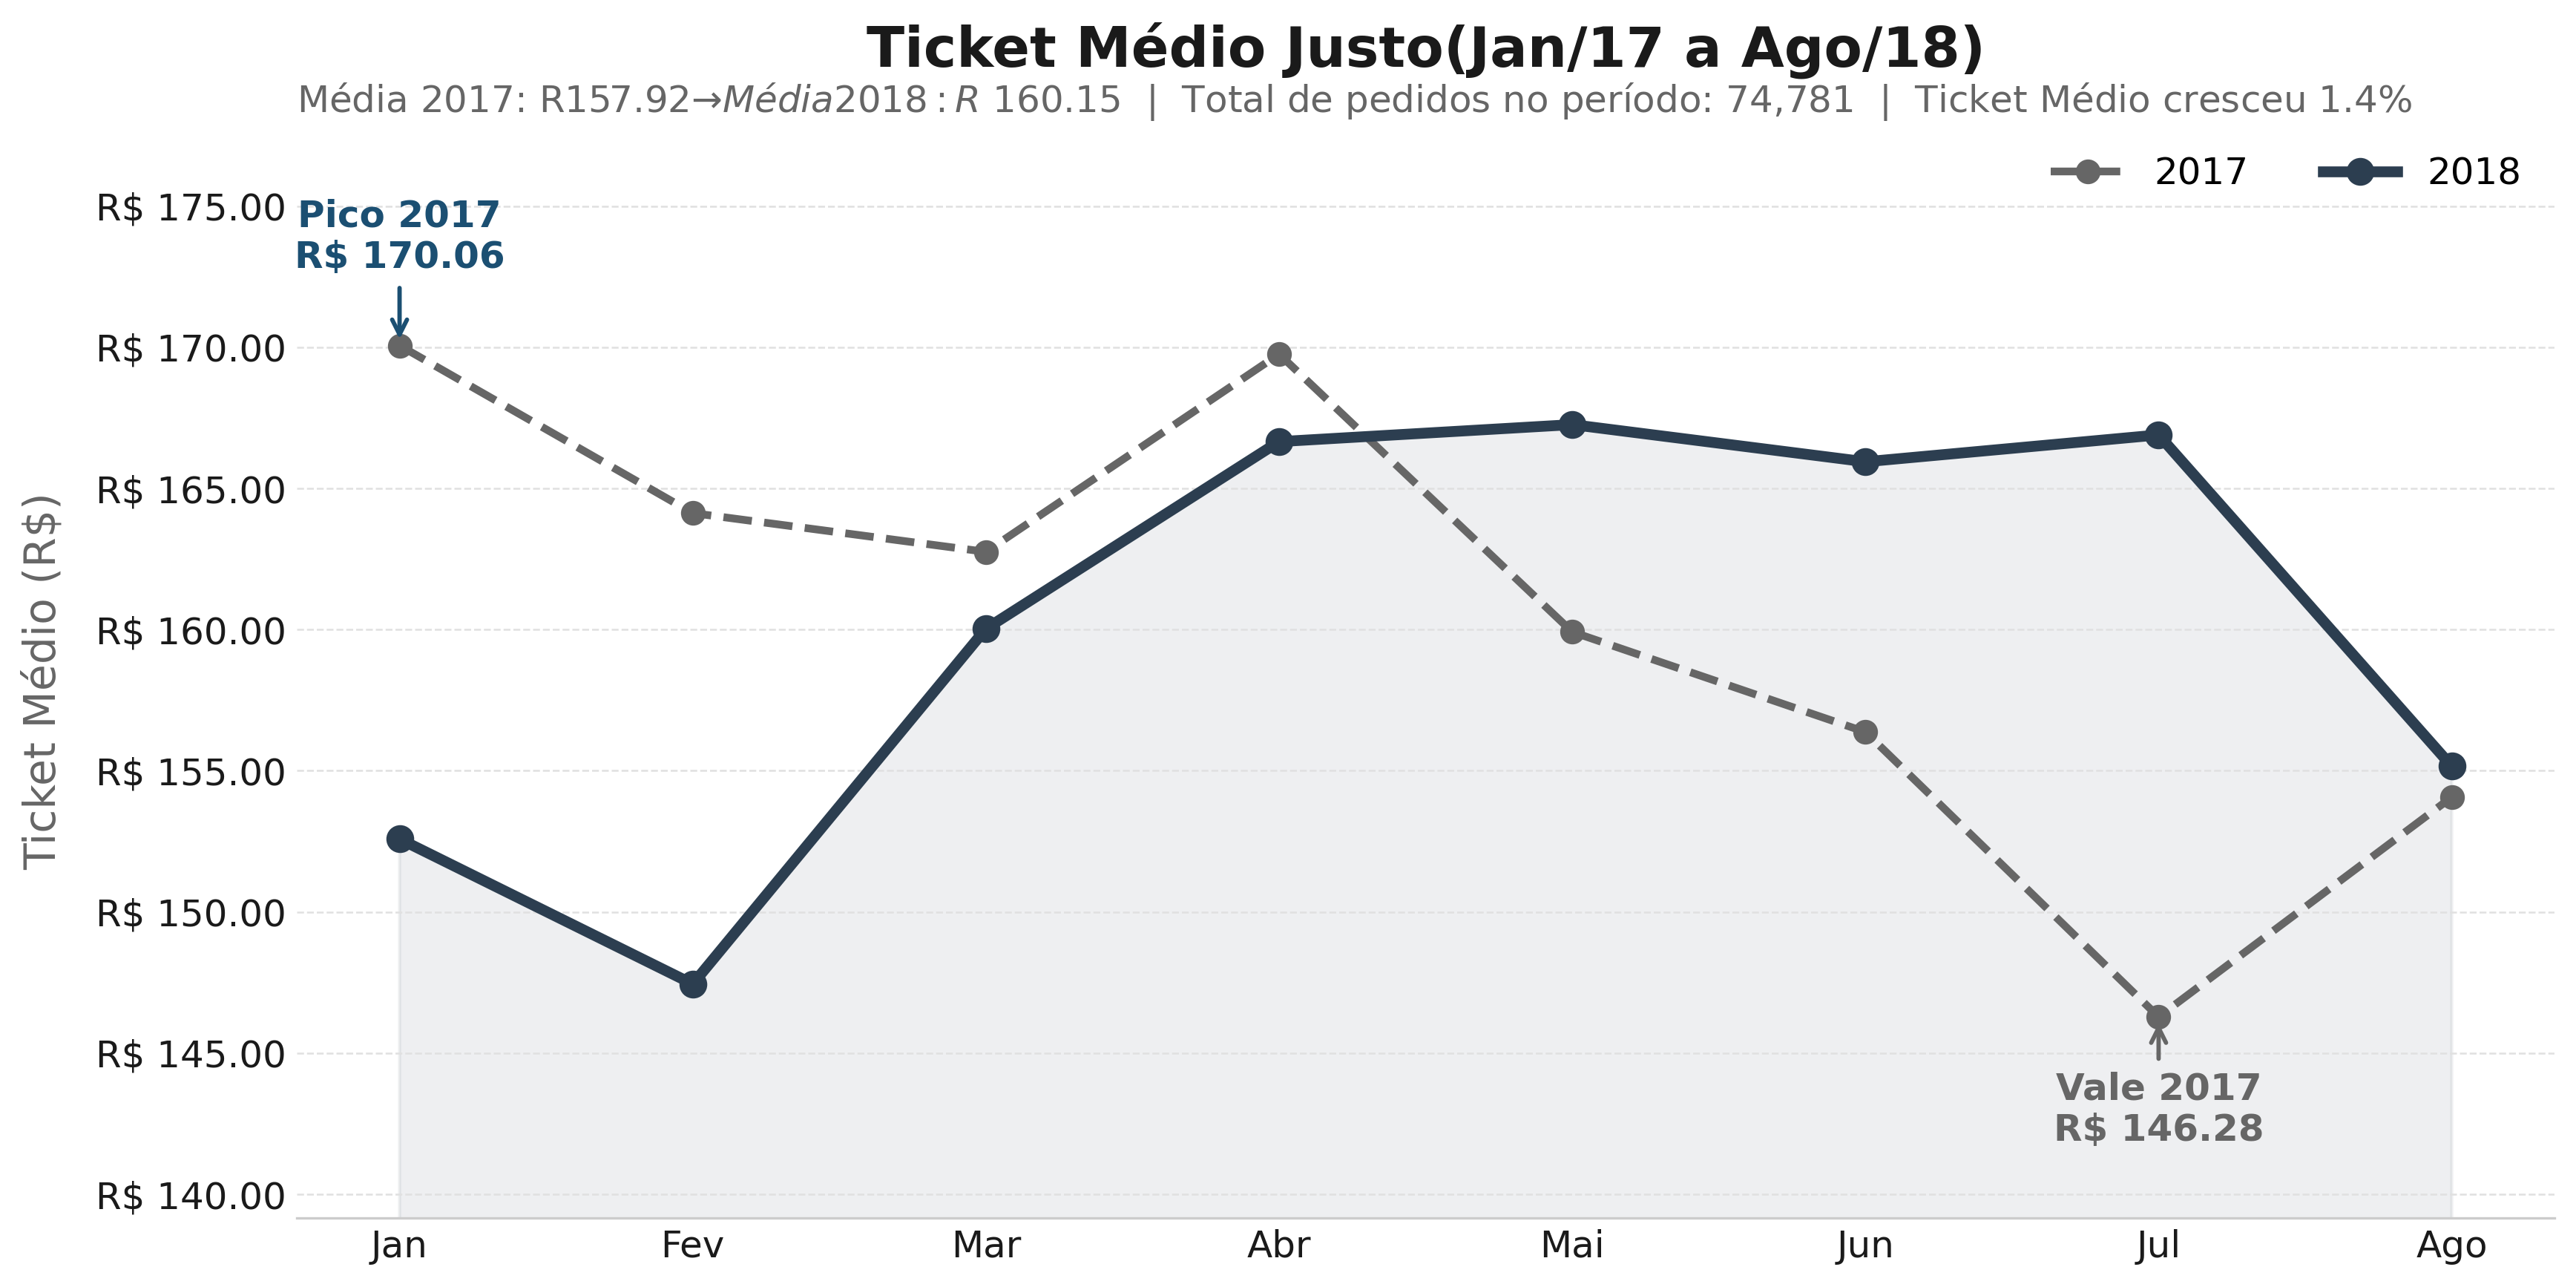

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Config global ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12
})

# ── Preparação dos dados ───────────────────────────────────────────────────────
df_plot = tabela_receita_mensal.copy()
df_plot['ano_mes_dt'] = pd.to_datetime(df_plot['ano_mes'].astype(str))
df_plot['ano'] = df_plot['ano_mes_dt'].dt.year
df_plot['mes'] = df_plot['ano_mes_dt'].dt.month

df_justo = df_plot[(df_plot['mes'] <= 8) & (df_plot['ano'].isin([2017, 2018]))].copy()

df_2017 = df_justo[df_justo['ano'] == 2017].sort_values('mes')
df_2018 = df_justo[df_justo['ano'] == 2018].sort_values('mes')

# ── Métricas ───────────────────────────────────────────────────────────────────
ticket_2017 = df_2017['receita_total'].sum() / df_2017['qtd_pedidos'].sum()
ticket_2018 = df_2018['receita_total'].sum() / df_2018['qtd_pedidos'].sum()
variacao_pct = ((ticket_2018 - ticket_2017) / ticket_2017) * 100
direcao = "cresceu" if variacao_pct > 0 else "caiu"
total_pedidos = df_justo['qtd_pedidos'].sum()
ticket_medio_geral = df_justo['ticket_medio'].mean()

row_pico = df_justo.loc[df_justo['ticket_medio'].idxmax()]
row_vale = df_justo.loc[df_justo['ticket_medio'].idxmin()]

meses_nomes = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago']

# ── Canvas ─────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6), dpi=300)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# ── Linhas ─────────────────────────────────────────────────────────────────────
ax.plot(
    meses_nomes,
    df_2017['ticket_medio'],
    color=CINZA_SUB,
    linewidth=2.5,
    linestyle='--',
    marker='o',
    markersize=7,
    zorder=3,
    label='2017'
)

ax.plot(
    meses_nomes,
    df_2018['ticket_medio'],
    color=AZUL_ESCURO,
    linewidth=3.5,
    marker='o',
    markersize=8,
    zorder=4,
    label='2018'
)

ax.fill_between(
    meses_nomes,
    df_2018['ticket_medio'],
    alpha=0.08,
    color=AZUL_ESCURO,
)

# ── Anotações ──────────────────────────────────────────────────────────────────
x_pico = meses_nomes[int(row_pico['mes']) - 1]
ax.annotate(
    f"Pico {int(row_pico['ano'])}\nR$ {row_pico['ticket_medio']:,.2f}",
    xy=(x_pico, row_pico['ticket_medio']),
    xytext=(0, 25),
    textcoords='offset points',
    ha='center',
    fontsize=12,
    fontweight='bold',
    color=COR_PICO,
    arrowprops=dict(arrowstyle='->', color=COR_PICO, lw=1.4),
)

x_vale = meses_nomes[int(row_vale['mes']) - 1]
ax.annotate(
    f"Vale {int(row_vale['ano'])}\nR$ {row_vale['ticket_medio']:,.2f}",
    xy=(x_vale, row_vale['ticket_medio']),
    xytext=(0, -40),
    textcoords='offset points',
    ha='center',
    fontsize=12,
    fontweight='bold',
    color=CINZA_SUB,
    arrowprops=dict(arrowstyle='->', color=CINZA_SUB, lw=1.4),
)

# ── Eixos ──────────────────────────────────────────────────────────────────────
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.2f}'))

plt.xticks(color=CINZA_TEXTO)
plt.yticks(color=CINZA_TEXTO)

margem = (df_justo['ticket_medio'].max() - df_justo['ticket_medio'].min()) * 0.3
ax.set_ylim(
    df_justo['ticket_medio'].min() - margem,
    df_justo['ticket_medio'].max() + margem,
)

ax.yaxis.grid(True, linestyle='--', linewidth=0.6, color='#e0e0e0', zorder=1)
ax.xaxis.grid(False)

ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(axis='both', length=0)

# ── Títulos ───────────────────────────────────────────────────────────────────
ax.set_title(
    f'Ticket Médio Justo(Jan/17 a Ago/18)',
    fontsize=18,
    fontweight='bold',
    color=CINZA_TEXTO,
    pad=25,
    loc='center',
)

ax.text(
    0, 1.02,
    f'Média 2017: R$ {ticket_2017:,.2f}  →  Média 2018: R$ {ticket_2018:,.2f}  |  Total de pedidos no período: {total_pedidos:,.0f}  |  '
    f'Ticket Médio {direcao} {abs(variacao_pct):.1f}%',
    transform=ax.transAxes,
    fontsize=12,
    color=CINZA_SUB,
    va='bottom',
)

ax.set_xlabel('')
ax.set_ylabel('Ticket Médio (R$)', fontsize=14, color=CINZA_SUB, labelpad=10)

# ── Legenda (AJUSTADA AQUI) ───────────────────────────────────────────────────
ax.legend(
    frameon=False,
    loc='upper right',
    bbox_to_anchor=(1.0, 1.02),  # ↓ ajuste para não colidir com título
    ncol=3
)

plt.tight_layout()
plt.savefig('ticket_medio_justo_word.png', dpi=300, bbox_inches='tight')
plt.show()

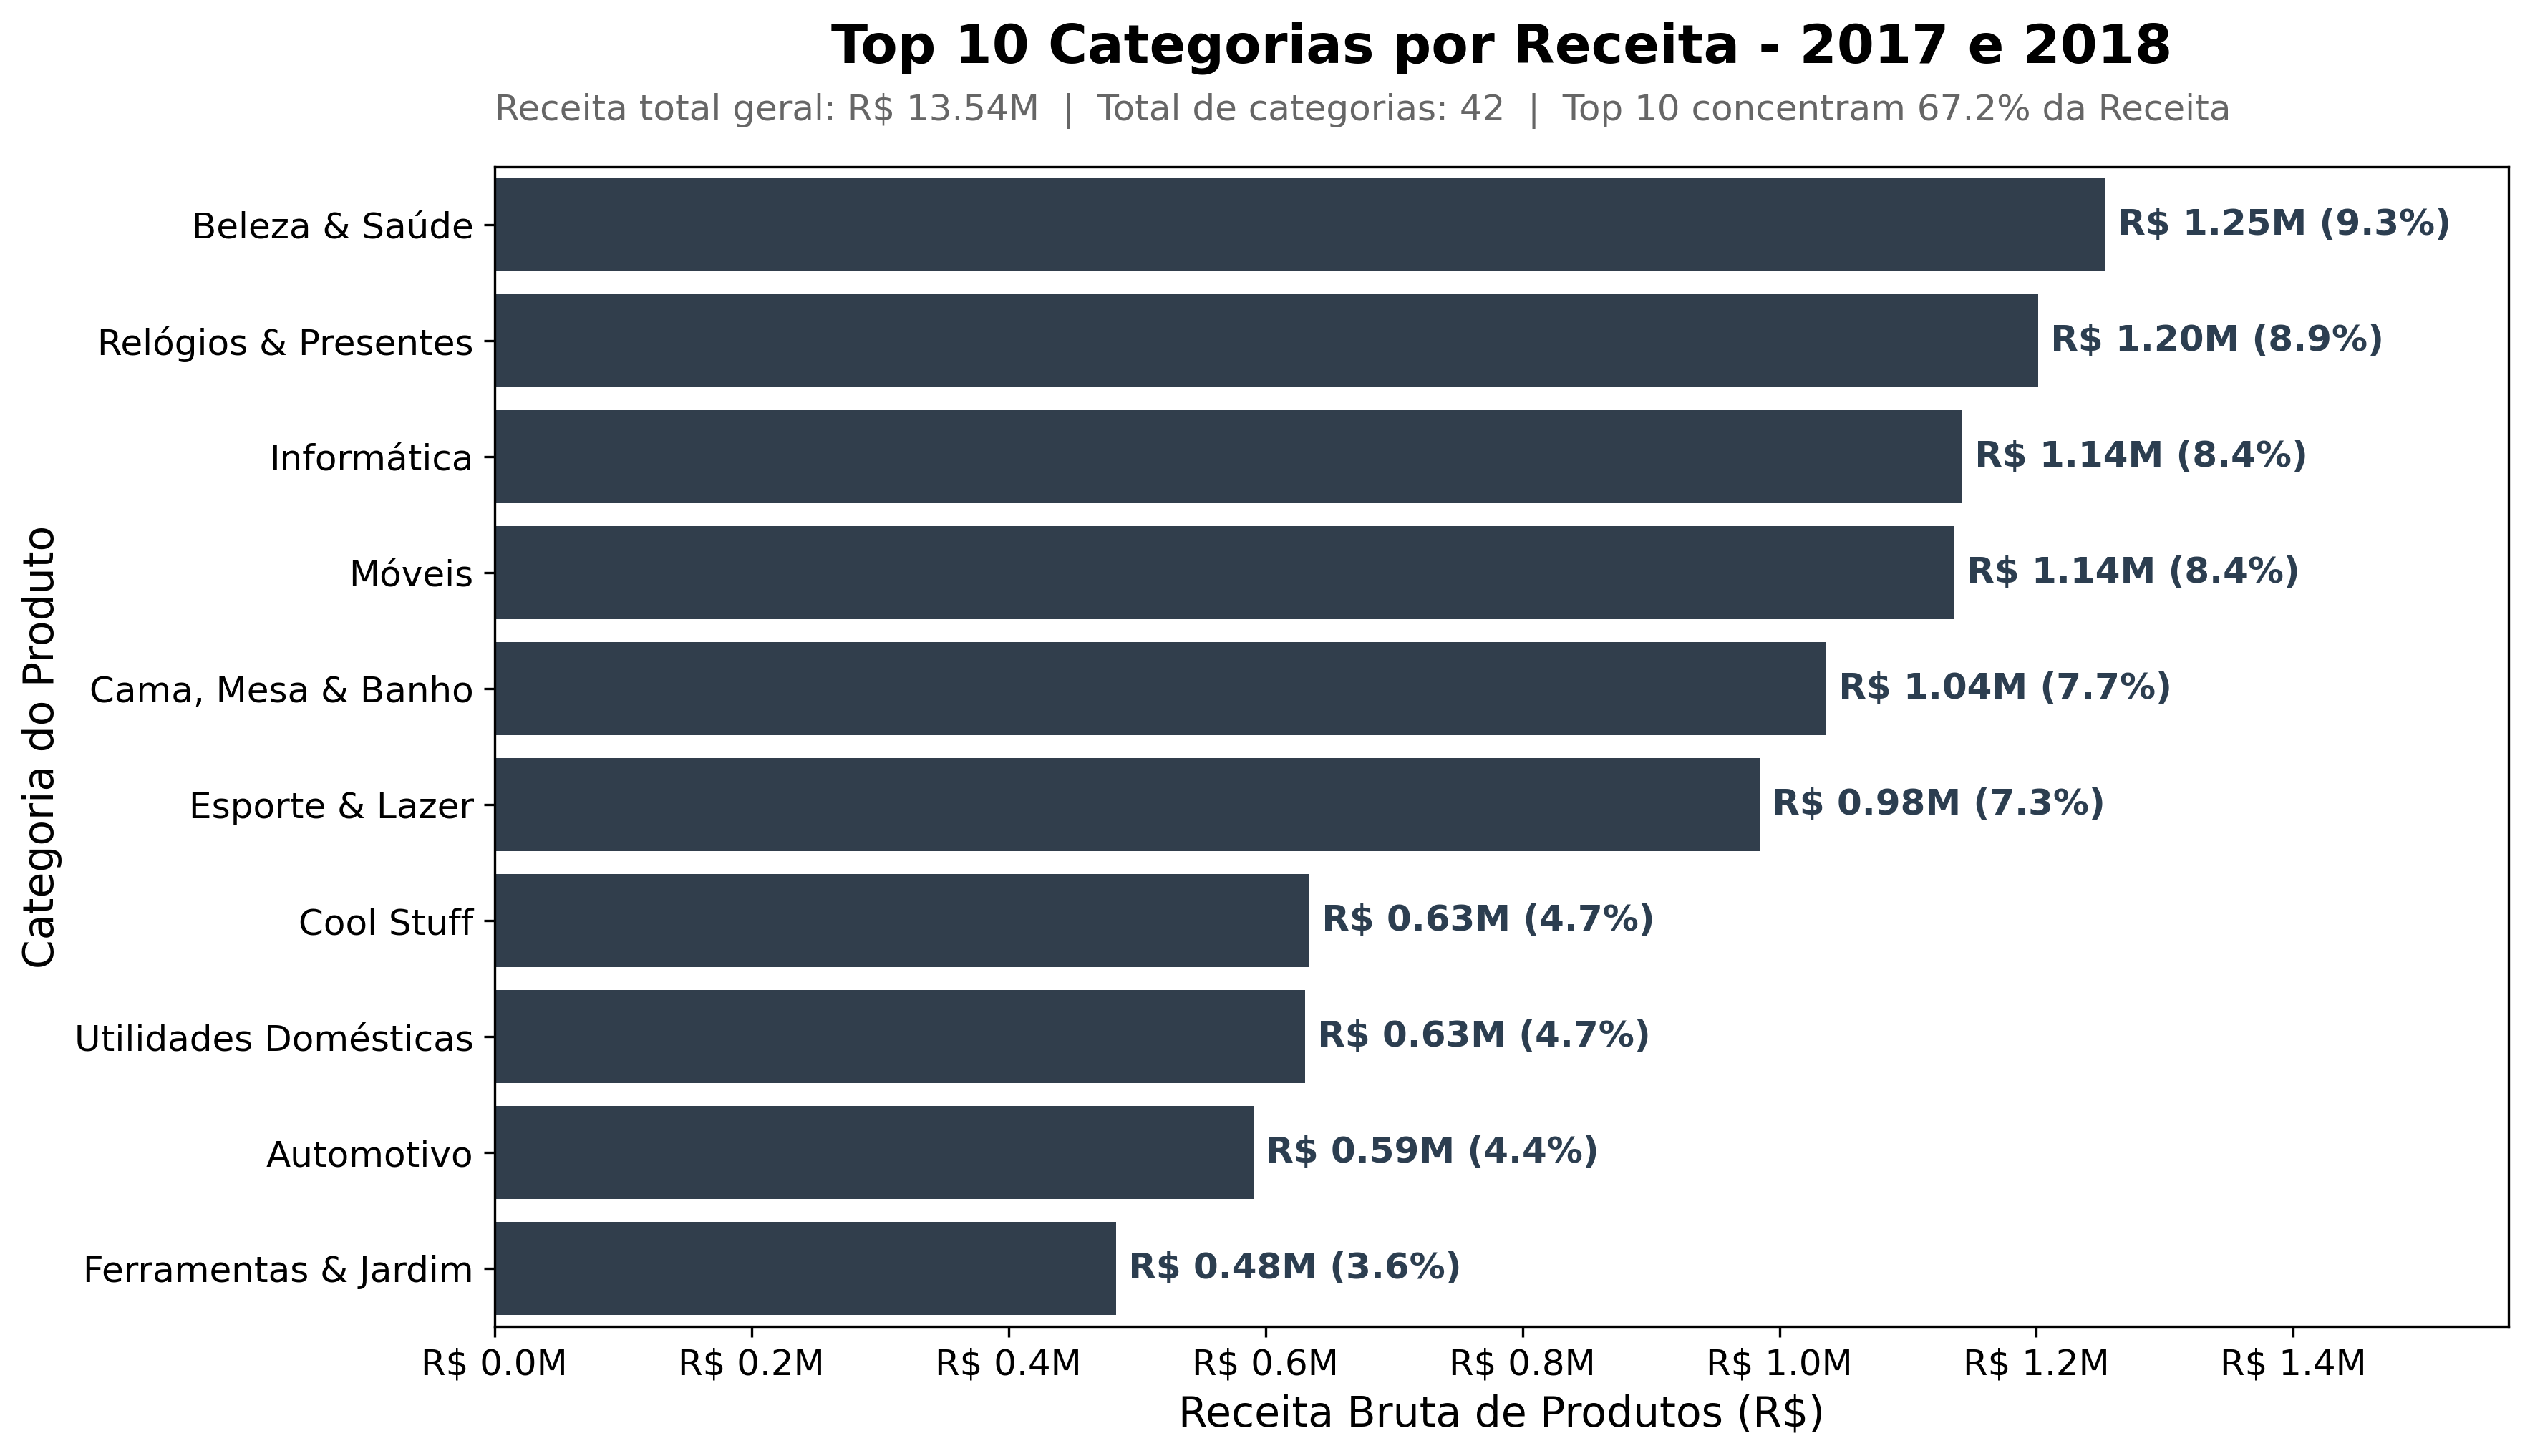

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ── Config global ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

# ── Função para formatar nomes ────────────────────────────────────────────────
def formatar_categoria(cat):
    cat = cat.replace('_', ' ').title()

    ajustes = {
        'Beleza Saude': 'Beleza & Saúde',
        'Cama Mesa Banho': 'Cama, Mesa & Banho',
        'Esporte Lazer': 'Esporte & Lazer',
        'Utilidades Domesticas': 'Utilidades Domésticas',
        'Moveis': 'Móveis',
        'Informatica': 'Informática',
        'Relogios Presentes': 'Relógios & Presentes',
        'Ferramentas Jardim': 'Ferramentas & Jardim'
    }

    return ajustes.get(cat, cat)

# Criando coluna formatada (sem alterar original)
tabela_top10['categoria_formatada'] = tabela_top10['product_category_clean'].apply(formatar_categoria)

# ── Métricas ──────────────────────────────────────────────────────────────────
receita_total_geral = tabela_categorias['receita_produtos'].sum()
n_categorias        = tabela_categorias['product_category_clean'].nunique()
top10_share = tabela_top10['receita_produtos'].sum() / receita_total_geral * 100

# ── Canvas ────────────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 7), dpi=300)

sns.barplot(
    data=tabela_top10,
    y='categoria_formatada',
    x='receita_produtos',
    color='#2c3e50'
)

plt.title('Top 10 Categorias por Receita - 2017 e 2018', fontsize=18, fontweight='bold', pad=35)
plt.xlabel('Receita Bruta de Produtos (R$)', fontsize=14)
plt.ylabel('Categoria do Produto', fontsize=14)

# ── Formatação eixo X ─────────────────────────────────────────────────────────
plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, pos: f'R$ {x/1000000:.1f}M')
)

xmax = tabela_top10['receita_produtos'].max()
plt.xlim(0, xmax * 1.25)

# ── Labels nas barras ─────────────────────────────────────────────────────────
for index, row in tabela_top10.reset_index(drop=True).iterrows():
    valor = row['receita_produtos']
    perc = row['porcentagem']
    texto_label = f' R$ {valor/1000000:.2f}M ({perc:.1f}%)'

    plt.text(
        valor,
        index,
        texto_label,
        va='center',
        fontsize=12,
        fontweight='bold',
        color='#2c3e50'
    )

# ── Subtítulo ─────────────────────────────────────────────────────────────────
texto_subtitulo = (
    f"Receita total geral: R$ {receita_total_geral/1e6:.2f}M  |  " +
    f"Total de categorias: {n_categorias}  |  " +
    f"Top 10 concentram {top10_share:.1f}% da Receita"
)

plt.gca().text(
    0, 1.04,
    texto_subtitulo,
    transform=plt.gca().transAxes,
    fontsize=12,
    color='#666666',
    ha='left'
)

plt.tight_layout()

# ── Exportação ────────────────────────────────────────────────────────────────
plt.savefig('receita_categoria_word.png', dpi=300, bbox_inches='tight')

plt.show()

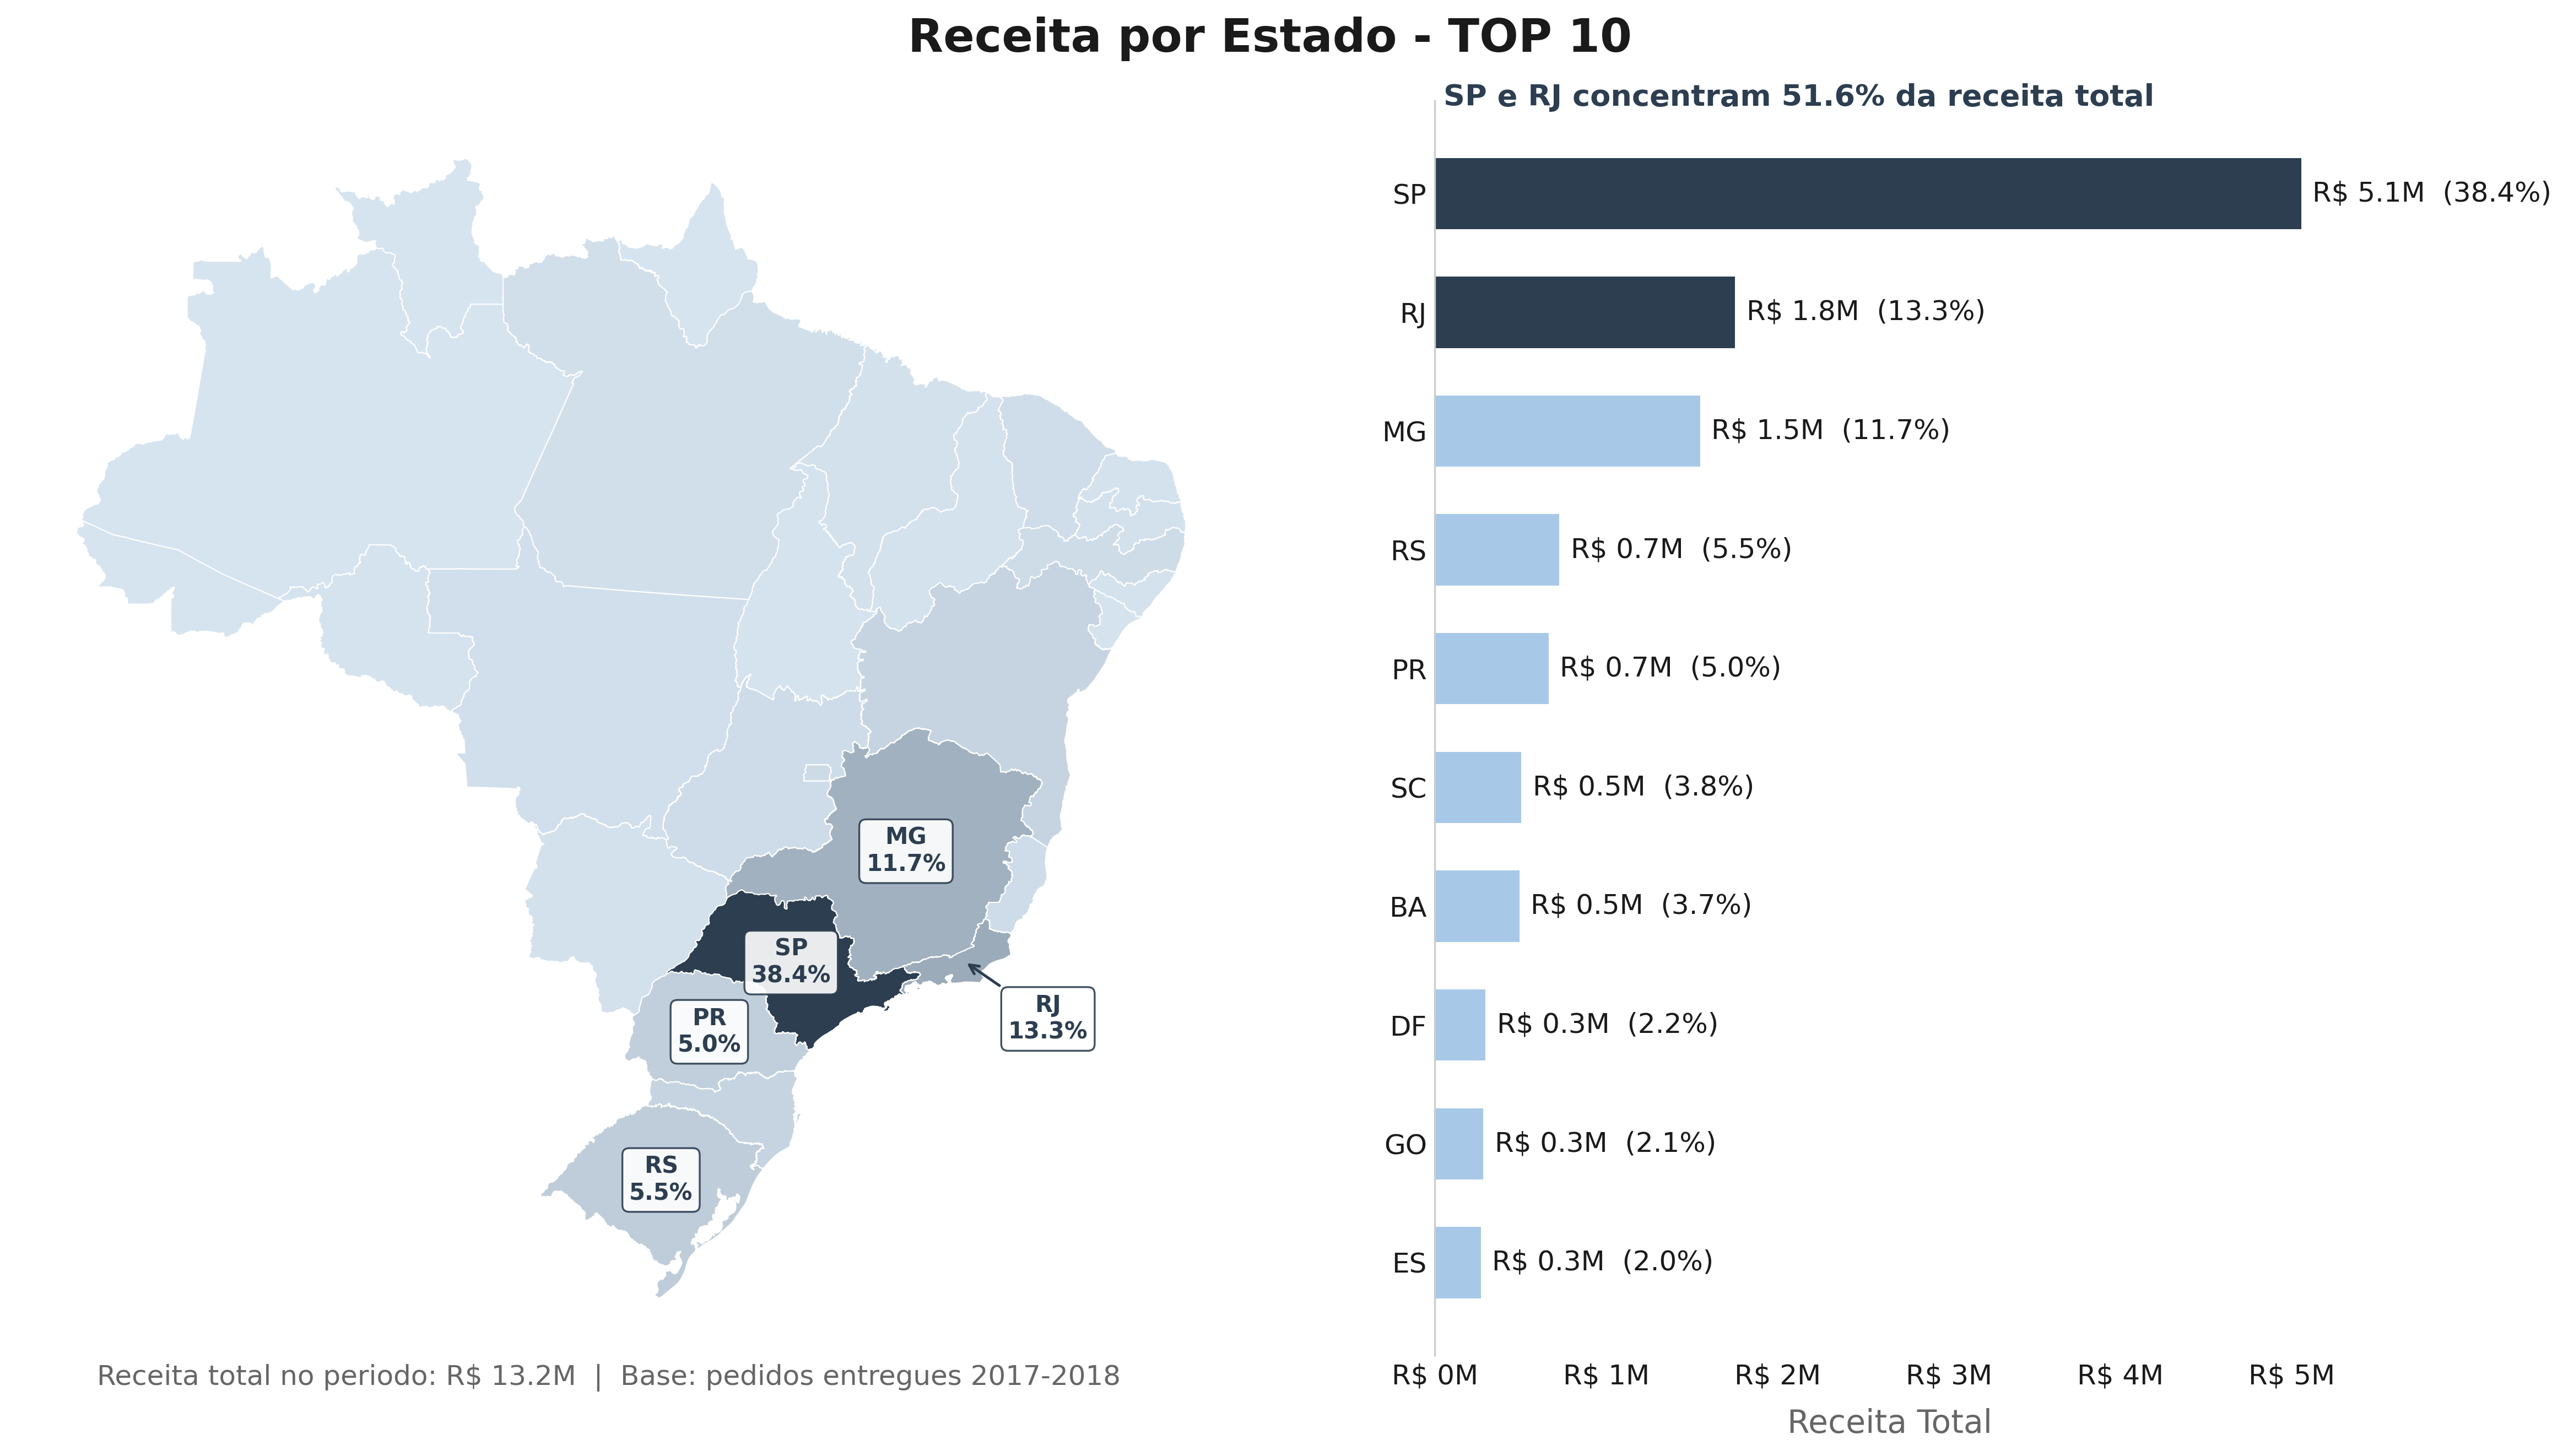

In [33]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
import geopandas as gpd
import requests
import io

# Avisos
import warnings
warnings.filterwarnings('ignore')

# ── Config global (PADRÃO WORD) ───────────────────────────────────────────────
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 18,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12
})

# ── Paleta ────────────────────────────────────────────────────────────────────
AZUL_ESCURO = '#2c3e50'
AZUL_CLARO  = '#a8c8e8'
CINZA_TEXTO = '#1A1A1A'
CINZA_SUB   = '#666666'
COR_PICO    = '#1b4f72'
LARANJA     = '#ff7f0e'

# ── Baixa o shapefile do Brasil por estado ────────────────────────────────────
url = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'
response = requests.get(url)
gdf = gpd.read_file(io.BytesIO(response.content))

gdf = gdf.rename(columns={'sigla': 'customer_state'})

# ── Merge ─────────────────────────────────────────────────────────────────────
gdf_merged = gdf.merge(
    tabela_receita_por_estado[['customer_state', 'receita_produtos']],
    on='customer_state',
    how='left'
)
gdf_merged['receita_produtos'] = gdf_merged['receita_produtos'].fillna(0)

# ── Métricas ──────────────────────────────────────────────────────────────────
receita_produtos_geral = tabela_receita_por_estado['receita_produtos'].sum()
top2 = tabela_receita_por_estado.head(2)
top2_receita = top2['receita_produtos'].sum()
top2_pct = (top2_receita / receita_produtos_geral) * 100
top2_estados = ' e '.join(top2['customer_state'].tolist())

df_top10 = tabela_receita_por_estado.head(10).sort_values('receita_produtos', ascending=True)

# ── Canvas (AJUSTADO) ─────────────────────────────────────────────────────────
fig, (ax_mapa, ax_bar) = plt.subplots(
    1, 2,
    figsize=(16, 9),  # melhor proporção pro Word
    dpi=300,          # alta resolução
    gridspec_kw={'width_ratios': [1.5, 1]}
)
fig.patch.set_facecolor('white')

# ───────────────── MAPA ─────────────────
ax_mapa.set_facecolor('white')

cmap = mcolors.LinearSegmentedColormap.from_list(
    'azul_gradiente', ['#d6e4f0', AZUL_ESCURO]
)

gdf_merged.plot(
    column='receita_produtos',
    cmap=cmap,
    linewidth=0.5,
    edgecolor='white',
    ax=ax_mapa,
    legend=False,
)

top5 = tabela_receita_por_estado.head(5)

offsets = {
    'SP': (0, 0),
    'RJ': (3, -2),
    'MG': (0, 0),
    'RS': (0, 0),
    'PR': (0, 0),
}

for _, row in top5.iterrows():
    estado = row['customer_state']
    pct = (row['receita_produtos'] / receita_produtos_geral) * 100
    geo_row = gdf_merged[gdf_merged['customer_state'] == estado]
    if not geo_row.empty:
        centroid = geo_row.geometry.centroid.iloc[0]
        ox, oy = offsets.get(estado, (0, 0))

        ax_mapa.annotate(
            f"{estado}\n{pct:.1f}%",
            xy=(centroid.x, centroid.y),
            xytext=(centroid.x + ox, centroid.y + oy),
            ha='center', va='center',
            fontsize=10,  # ↑ antes 7.5
            fontweight='bold',
            color=AZUL_ESCURO,
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=AZUL_ESCURO, lw=0.8, alpha=0.9),
            arrowprops=dict(arrowstyle='->', color=AZUL_ESCURO, lw=1.2),
        )

ax_mapa.set_axis_off()

# ───────────────── BAR CHART ─────────────────
ax_bar.set_facecolor('white')

cores_bar = [
    AZUL_ESCURO if i >= len(df_top10) - 2 else AZUL_CLARO
    for i in range(len(df_top10))
]

bars = ax_bar.barh(
    df_top10['customer_state'],
    df_top10['receita_produtos'],
    color=cores_bar,
    edgecolor='none',
    height=0.6,
)

for bar, val in zip(bars, df_top10['receita_produtos']):
    pct = (val / receita_produtos_geral) * 100
    ax_bar.text(
        bar.get_width() + receita_produtos_geral * 0.005,
        bar.get_y() + bar.get_height() / 2,
        f'R$ {val/1e6:.1f}M  ({pct:.1f}%)',
        va='center',
        fontsize=12,  # ↑ antes 10
        color=CINZA_TEXTO,
    )

ax_bar.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R$ {x/1e6:.0f}M')
)

ax_bar.tick_params(axis='both', length=0, colors=CINZA_TEXTO)
ax_bar.spines[['top', 'right', 'bottom']].set_visible(False)
ax_bar.spines['left'].set_color('#cccccc')

ax_bar.set_xlabel('Receita Total', fontsize=14, color=CINZA_SUB, labelpad=8)

# ── Título ────────────────────────────────────────────────────────────────────
fig.suptitle(
    'Receita por Estado - TOP 10',
    fontsize=20,
    fontweight='bold',
    color=CINZA_TEXTO,
    x=0.5,
    ha='center',
    y=0.98  # ↓ pequeno ajuste pra não cortar no Word
)

# Rodapé
fig.text(
    0.25, 0.06,
    f'Receita total no periodo: R$ {receita_produtos_geral/1e6:.1f}M  |  Base: pedidos entregues 2017-2018',
    fontsize=12,
    color=CINZA_SUB,
    ha='center'
)

# Destaque lateral
fig.text(
    0.70, 0.92,
    f'{top2_estados} concentram {top2_pct:.1f}% da receita total',
    fontsize=13,
    fontweight='bold',
    color=AZUL_ESCURO,
    ha='center'
)

plt.tight_layout()

# ── Exportação ────────────────────────────────────────────────────────────────
plt.savefig('receita_por_estado_word.png', dpi=300, bbox_inches='tight')

plt.show()